# Houses Prices Dataset - Exploratory Data Analysis

# Project Context
This notebook shows a rigorous exploratory data analysis of the Ames Houses Prices dataset from Kaggle

Our main objectives during this analysis are:

*   Initial Data Inspection
*   Univariate Analysis
* Multivariate Analysis
* Data Quality Deep Dive

Additionally we are looking to identify:

* Numerical Features
* Categorical Features
* Missing Data
* Outliers
* Variable Interactions


This EDA is made to work as a foundation of a full machine learning pipeline

# Problem Definition

We aim to predict the sale price of a house using its structured status information:

*   Task type: Linear Regression
*   Target variable: SalePrice



# Methodological Standard

This analysis follows professional data science practices:

* Clear distinction between types of variables
* Identification of the effects of interactions
* Explicit handling of missing data
* Reproducible structure
* Quantified decisions
* Strategic connection to modeling

# Expected Outcomes

By the end of this notebook, we will have:

1. Identified main predictors
2. Identified mostly useless features
3. Detected relationships between non target features
4. Diagnosed missingness mechanisms.
5. Proposed justified feature transformations.

This document works as a professional reference implementation of EDA.

# Setup and initial data inspection

We are gonna start importing the required libraries for this notebook and setting some styling for plots and tables.

Also we are going to load the dataset and take a glimpse at the data.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 83

DATA_DIR = Path("../data")
REPORTS_DIR = Path("../reports")

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 81)
pd.set_option("display.width", 150)
sns.set_style('whitegrid')

In [ ]:
url = 'https://raw.githubusercontent.com/errodd/Houses-Prices---ML-/refs/heads/EDA/data/houses_prices.csv'
df = pd.read_csv(url)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [ ]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
2914,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
2915,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
2916,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
2917,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,NaN,0.0,TA,TA,PConc,Gd,TA,Av,GLQ,337.0,Unf,0.0,575.0,912.0,GasA,TA,Y,SBrkr,970,0,0,970,0.0,1.0,1,0,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,80,32,0,0,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN
2918,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,2Story,7,5,1993,1994,Gable,CompShg,HdBoard,HdBoard,BrkFace,94.0,TA,TA,PConc,Gd,TA,Av,LwQ,758.0,Unf,0.0,238.0,996.0,GasA,Ex,Y,SBrkr,996,1004,0,2000,0.0,0.0,2,1,3,1,TA,9,Typ,1,TA,Attchd,1993.0,Fin,3.0,650.0,TA,TA,Y,190,48,0,0,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal,NaN


In [ ]:
df.shape

(2919, 81)

# Houses Prices EDA - Professional Standard

# Objective

Perform a rigorous data analysis to understand the house prices dataset and prepare preprocessing decisions for a future regression model.

# Target

*SalePrice* - Linear Regression

# Guiding questions

1. How many features do I have, and what's the split between numerical and categorical?
2. Are there any features that seem redundant or could be derived from others?
3. Is SalePrice normally distributed, or is it skewed?
4. Are there any extreme values that might be errors or legitimate luxury homes?
5. Are there features that should be numerical but are actually categorical?
6. How many unique values in each categorical feature?
7. Which features show the strongest relationship with SalePrice?
8. Why are values missing? Is it truly missing or "does not exist"?
9. Can and should i create new features by combining existing ones?
10. Can and should i create binary flags to represent certain categorical features?
11. Which skewed features might benefit from log transformation?


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC


Here we have real number (float) columns:
* LotFrontage (Linear feet of street connected to property)
* MasVnrArea (Masonry veneer area in square feet)
* BsmtFinSF1 (Type 1 finished square feet)
* BsmtFinSF2 (Type 2 finished square feet)
* BsmtUnfSF (Unfinished square feet of basement area)
* TotalBsmtSF (Total square feet of basement area)
* BsmtFullBath (Basement full bathrooms)
* BsmtHalfBath (Basement half bathrooms)
* GarageYrBlt (Year garage was built)
* GarageCars (Size of garage in car capacity)
* GarageArea (Size of garage in square feet)

The integer number columns are:
* Id
* MSSubClass (Identifies the type of dwelling involved in the sale)
* LotArea (Lot size in square feet)
* OverallQual (Rates the overall material and finish of the house)
* OverallCond (Rates the overall condition of the house)
* YearBuilt (Original construction date)
* YearRemodAdd (Remodel date (same as construction date if no remodeling or additions))
* 1stFlrSF (First Floor square feet)
* 2ndFlrSF (Second floor square feet)
* LowQualFinSF (Low quality finished square feet (all floors))
* GrLivArea (Above grade (ground) living area square feet)
* FullBath (Full bathrooms above grade)
* HalfBath (Half baths above grade)
* BedroomAbvGr (Bedrooms above grade (does NOT include basement bedrooms))
* KitchenAbvGr (Kitchens above grade)
* TotRmsAbvGrd (Total rooms above grade (does not include bathrooms))
* Fireplaces (Number of fireplaces)
* WoodDeckSF (Wood deck area in square feet)
* OpenPorchSF (Open porch area in square feet)
* EnclosedPorch (Enclosed porch area in square feet)
* 3SsnPorch (Three season porch area in square feet)
* ScreenPorch (Screen porch area in square feet)
* PoolArea (Pool area in square feet)
* MiscVal ($Value of miscellaneous feature)
* MoSold (Month Sold (MM))
* YrSold (Year Sold (YYYY))

The object columns(most commonly strings, although they could also be float or integer numbers) are:
* MSZoning (Identifies the general zoning classification of the sale.)
* Street (Type of road access to property)
* Alley (Type of alley access to property)
* LotShape (General shape of property)
* LandContour (Flatness of the property)
* Utilities (Type of utilities available)
* LotConfig (Lot configuration)
* LandSlope (Slope of property)
* Neighborhood (Physical locations within Ames city limits)
* Condition1 (Proximity to various conditions)
* Condition2 (Proximity to various conditions (if more than one is present))
* BldgType (Type of dwelling)
* HouseStyle (Style of dwelling)
* RoofStyle (Type of roof)
* RoofMatl (Roof material)
* Exterior1st (Exterior covering on house)
* Exterior2nd (Exterior covering on house (if more than one material))
* MasVnrType (Masonry veneer type)
* ExterQual (Evaluates the quality of the material on the exterior )
* ExterCond (Evaluates the present condition of the material on the exterior)
* Foundation (Type of foundation)
* BsmtQual (Evaluates the height of the basement)
* BsmtCond (Evaluates the general condition of the basement)
* BsmtExposure (Refers to walkout or garden level walls)
* BsmtFinType1 (Rating of basement finished area)
* BsmtFinType2 (Rating of basement finished area (if multiple types))
* Heating (Type of heating)
* HeatingQC (Heating quality and condition)
* CentralAir (Central air conditioning)
* Electrical (Electrical system)
* KitchenQual (Kitchen quality)
* Functional (Home functionality (Assume typical unless deductions are warranted))
* FireplaceQu (Fireplace quality)
* GarageType (Garage location)
* GarageFinish (Interior finish of the garage)
* GarageQual (Garage quality)
* GarageCond (Garage condition)
* PavedDrive (Paved driveway)
* PoolQC (Pool quality)
* Fence (Fence quality)
* MiscFeature (Miscellaneous feature not covered in other categories)
* SaleType (Type of sale)
* SaleCondition (Condition of sale)

The target column (float number) is:
* SalePrice (Sale price of house)

# Basic Data cleansing and columns division

We are going to follow the next steps
1. Check to see if there are any completely empty columns or rows, if there are those are completely useless and need to be dropped.
2. Set the Id column as the index, given that we have no additional dataset file, this feature will not contribute any relevant data. This is common practice for this dataset.
3. We are going to divide our columns into our target, numerical features and categorical features.

In [ ]:
empty_cols = [col for col in df.columns if df[col].isnull().all()]
print("Empty columns:", empty_cols)

Empty columns: []


In [ ]:
has_empty_rows = (df.isnull().all(axis=1)).any()
print("Has any completely empty row:", has_empty_rows)

Has any completely empty row: False


As we see here we have no completely empty columns or rows

In [ ]:
df.set_index('Id', inplace=True)

# Basic Data cleansing and columns division - Dividing numerical features with categorical features

Before starting our analysis of features and target we have to divide each feature into numerical or categorical, to see which features are categorical we need to check for amount of unique values by total values (how many times each value appears), doing an heuristic check (with a 1% threshold to be absolutely sure) we can see which features are categorical.

In [ ]:
df_categorical = pd.DataFrame()
for col in df.columns:
    unique_count = df[col].nunique()
    total_count = df[col].count()
    if unique_count / total_count < 0.01:
        print(f"Column '{col}' is likely categorical (heuristic check).")
        df_categorical[col] = df[col]

Column 'MSSubClass' is likely categorical (heuristic check).
Column 'MSZoning' is likely categorical (heuristic check).
Column 'Street' is likely categorical (heuristic check).
Column 'LotShape' is likely categorical (heuristic check).
Column 'LandContour' is likely categorical (heuristic check).
Column 'Utilities' is likely categorical (heuristic check).
Column 'LotConfig' is likely categorical (heuristic check).
Column 'LandSlope' is likely categorical (heuristic check).
Column 'Neighborhood' is likely categorical (heuristic check).
Column 'Condition1' is likely categorical (heuristic check).
Column 'Condition2' is likely categorical (heuristic check).
Column 'BldgType' is likely categorical (heuristic check).
Column 'HouseStyle' is likely categorical (heuristic check).
Column 'OverallQual' is likely categorical (heuristic check).
Column 'OverallCond' is likely categorical (heuristic check).
Column 'RoofStyle' is likely categorical (heuristic check).
Column 'RoofMatl' is likely categ


From this result we can extract our categorical features.

However of these, in the case of numerical categories, we need to be sure that integers represent labels rather than measurements, in case of the houses, we can have many false positives in features which usually have low amounts like amount of bathrooms, kitchens, bedrooms and total rooms, to see those more easily lets check categories candidates which are numerical.

In [ ]:
df_categories_numerical = df_categorical.select_dtypes(include=[np.number])
df_categories_numerical.head()

,MSSubClass,OverallQual,OverallCond,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,PoolArea,MoSold,YrSold
Id,,,,,,,,,,,,,,,
1,60,7,5,1.0,0.0,2,1,3,1,8,0,2.0,0,2,2008
2,20,6,8,0.0,1.0,2,0,3,1,6,1,2.0,0,5,2007
3,60,7,5,1.0,0.0,2,1,3,1,6,1,2.0,0,9,2008
4,70,7,5,1.0,0.0,1,0,3,1,7,1,3.0,0,2,2006
5,60,8,5,1.0,0.0,2,1,4,1,9,1,3.0,0,12,2008


Of these, based on abbreviation definitions, we can discard from categorical features the following ones: BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, TotRmsAbvGrd, Fireplaces, GarageCars, PoolArea, YrSold.

In [ ]:

df_categorical = df_categorical.drop(columns=['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'PoolArea', 'YrSold'])
df_categorical.head()

,MSSubClass,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,Fence,MoSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,NaN,Attchd,RFn,TA,TA,Y,NaN,2,WD,Normal
2,20,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,Gable,CompShg,MetalSd,MetalSd,NaN,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,5,WD,Normal
3,60,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,9,WD,Normal
4,70,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,Wd Sdng,Wd Shng,NaN,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,GasA,Gd,Y,SBrkr,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,NaN,2,WD,Abnorml
5,60,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,12,WD,Normal


Here we can see the head of the dataframe that have every categorical feature (ordinal and nominal)

Now we can check how many unique values each categorical feature have, this will help us decide which encoding technique we will use in the Data Processing phase.

In [ ]:
df_categorical.nunique().sort_values(ascending=False)

,0
Neighborhood,25
MSSubClass,16
Exterior2nd,16
Exterior1st,15
MoSold,12
OverallQual,10
OverallCond,9
SaleType,9
Condition1,9
RoofMatl,8


In [ ]:
df_categorical.shape

(2919, 44)

As we see we can be sure that 44 out of the 79 features are categorical.


Now, to see which features are numerical(integer, float, etc) we select features of which data type is numerical from our base dataframe. And from this new numerical dataframe we remove the categorical numerical features that are there.

In [ ]:
full_categorical_list = df_categorical.columns.tolist()
df_cat_numerical = df_categorical.select_dtypes(include=[np.number])
categorical_list = df_cat_numerical.columns.tolist()

In [ ]:
df_numerical = df.select_dtypes(include=[np.number])
df_numerical = df_numerical.drop(columns=["SalePrice"])
df_numerical = df_numerical.drop(columns=categorical_list)
df_numerical.head()

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,65.0,8450,2003,2003,196.0,706.0,0.0,150.0,856.0,856,854,0,1710,1.0,0.0,2,1,3,1,8,0,2003.0,2.0,548.0,0,61,0,0,0,0,0,2008
2,80.0,9600,1976,1976,0.0,978.0,0.0,284.0,1262.0,1262,0,0,1262,0.0,1.0,2,0,3,1,6,1,1976.0,2.0,460.0,298,0,0,0,0,0,0,2007
3,68.0,11250,2001,2002,162.0,486.0,0.0,434.0,920.0,920,866,0,1786,1.0,0.0,2,1,3,1,6,1,2001.0,2.0,608.0,0,42,0,0,0,0,0,2008
4,60.0,9550,1915,1970,0.0,216.0,0.0,540.0,756.0,961,756,0,1717,1.0,0.0,1,0,3,1,7,1,1998.0,3.0,642.0,0,35,272,0,0,0,0,2006
5,84.0,14260,2000,2000,350.0,655.0,0.0,490.0,1145.0,1145,1053,0,2198,1.0,0.0,2,1,4,1,9,1,2000.0,3.0,836.0,192,84,0,0,0,0,0,2008


In [ ]:
df_numerical.shape

(2919, 32)

We end up having 32 out of the 79 features that are numerical. However we are missing three features, which by process of elimination are...

In [ ]:
numerical_list = df_numerical.columns.tolist()

In [ ]:
df_rest = df
df_rest = df_rest.drop(columns=full_categorical_list)
df_rest = df_rest.drop(columns=numerical_list)
df_rest = df_rest.drop(columns=['SalePrice'])
df_rest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 1 to 2919
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Alley        198 non-null    object
 1   PoolQC       10 non-null     object
 2   MiscFeature  105 non-null    object
dtypes: object(3)
memory usage: 91.2+ KB


# Basic Data cleansing and columns division - Other features

We are gonna start our univariate feature analysis with these features that apparently does not qualify as either categorical or numerical. First we are going to check their possible values, and value counts, to double check if they are categorical features.

In [ ]:
for col in df_rest.columns:
  print(df_rest[col].value_counts())

Alley
Grvl    120
Pave     78
Name: count, dtype: int64
PoolQC
Ex    4
Gd    4
Fa    2
Name: count, dtype: int64
MiscFeature
Shed    95
Gar2     5
Othr     4
TenC     1
Name: count, dtype: int64


Based on the possible values we can safely say these are features. And based on the unique values(and domain knowledge) we can see that PoolQC is an ordinal category, MiscFeature is a nominal category and Alley is also a nominal category.

Now we can see that the problem is that these categorical features are that they have enough null values to fail the heuristic check. Given that, for the regression model it would be highly recommended to just remove them. However we are going to talk about missing values further in the Data Quality Deep Dive section of the EDA, to check their real power. Lets first add them to the categorical dataframe.

In [ ]:
df_categorical['Alley'] = df['Alley']
df_categorical['PoolQC'] = df['PoolQC']
df_categorical['MiscFeature'] = df['MiscFeature']
df_categorical.head()

,MSSubClass,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,Fence,MoSold,SaleType,SaleCondition,Alley,PoolQC,MiscFeature
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,NaN,Attchd,RFn,TA,TA,Y,NaN,2,WD,Normal,NaN,NaN,NaN
2,20,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,Gable,CompShg,MetalSd,MetalSd,NaN,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,5,WD,Normal,NaN,NaN,NaN
3,60,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,9,WD,Normal,NaN,NaN,NaN
4,70,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,Wd Sdng,Wd Shng,NaN,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,GasA,Gd,Y,SBrkr,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,NaN,2,WD,Abnorml,NaN,NaN,NaN
5,60,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,12,WD,Normal,NaN,NaN,NaN


# Basic Data cleansing and columns division - Guiding Questions answers

1. How many features do I have, and what's the split between numerical and
categorical?

We have 79 features, 47 categorical and 32 numerical.

5. Are there features that should be numerical but are actually categorical?

Four, these are: MSSubClass, OverallQual, OverallCond and MoSold

6. How many unique values in each categorical feature?

They range from 2 to 25.

# Univariate Analysis

Here we are going to analyze single columns, to see each column behavior, starting with the target variable, then with our features.




# Univariate Analysis - Target (SalePrice)

We are going to start the univariate analysis by analysing our target variable - SalePrice

First we are going to create a Histogram of SalePrice to check for skewness

[]

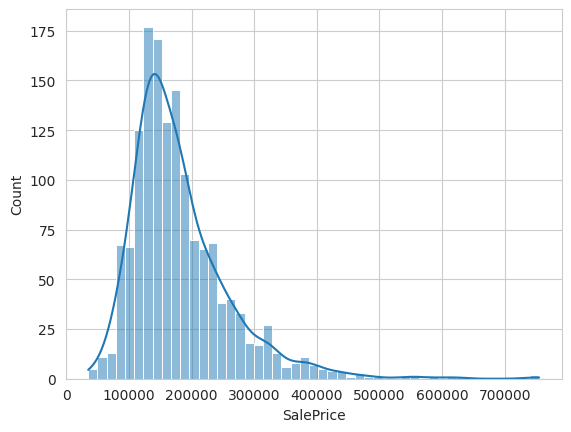

In [ ]:
sns.histplot(data=df, x="SalePrice", kde=True)
plt.plot()

We can easily observe that the target variable(SalePrice) have a long and thin tail to the right of the histogram, that means SalePrice is right-skewed.

Now we are going to calculate important statistical values of our target variable(mean, median, standard deviation and skewness).

In [ ]:
stats = df['SalePrice'].agg(['mean', 'median', 'std', 'skew'])
print(stats)

mean      180921.195890
median    163000.000000
std        79442.502883
skew           1.882876
Name: SalePrice, dtype: float64


Here we can see the target variable skewness is above 1, that means is highly skewed to the right, as we previously saw in the histogram for SalePrice.

Logarithmic transformation are applied to right skewed target (or features) to normalize data distributions, reduce the influence of extreme outliers, and linearize non-linear relationships, improving future model performance and interpretability.

Because of that, is recommended for this variable(SalePrice) to do a logarithmic transformation, or a Box-Cox for more flexibility.

# Univariate Analysis - Numerical Features

We are going to start our analysis on the numerical features, our goal is to check for strange or skewed distributions, unusual zeros, and strange min/max values across all numerical features.

We can begin by making histograms for each of these features, here we can check any strange or skewed distributions.

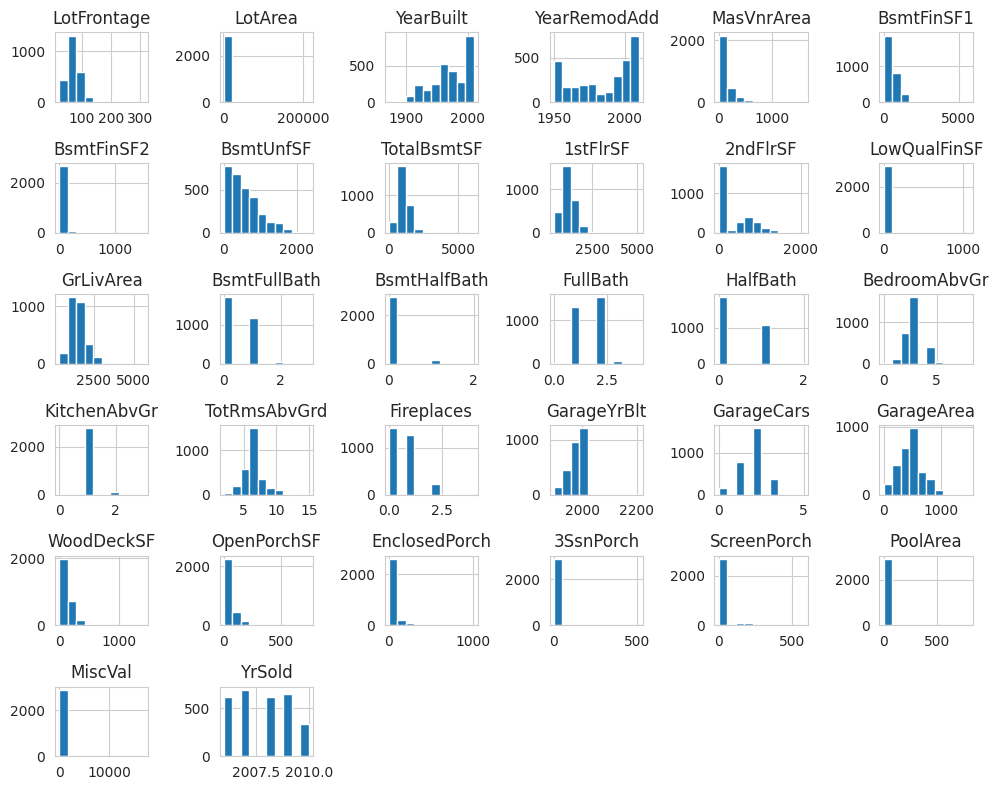

In [ ]:
df_numerical.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

Also we can generate summary statistics of each of these features

In [ ]:
df_numerical.describe()

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold
count,2433.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,2918.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2917.000000,2917.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2760.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,69.305795,10168.114080,1971.312778,1984.264474,102.201312,441.423235,49.582248,560.772104,1051.777587,1159.581706,336.483727,4.694416,1500.759849,0.429894,0.061364,1.568003,0.380267,2.860226,1.044536,6.451524,0.597122,1978.113406,1.766621,472.874572,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,2007.792737
std,23.344905,7886.996359,30.291442,20.894344,179.334253,455.610826,169.205611,439.543659,440.766258,392.362079,428.701456,46.396825,506.051045,0.524736,0.245687,0.552969,0.502872,0.822693,0.214462,1.569379,0.646129,25.574285,0.761624,215.394815,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,1.314964
min,21.000000,1300.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2006.000000
25%,59.000000,7478.000000,1953.500000,1965.000000,0.000000,0.000000,0.000000,220.000000,793.000000,876.000000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2007.000000
50%,68.000000,9453.000000,1973.000000,1993.000000,0.000000,368.500000,0.000000,467.000000,989.500000,1082.000000,0.000000,0.000000,1444.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000
75%,80.000000,11570.000000,2001.000000,2004.000000,164.000000,733.000000,0.000000,805.500000,1302.000000,1387.500000,704.000000,0.000000,1743.500000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2009.000000
max,313.000000,215245.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,2010.000000


 Of these features we can see some unusual zeros, specifically in the third quartile. I refer to the following features: BsmtFinSF2, LowQualFinSF, BsmtHalfBath, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea and MiscVal. This means that these features are very heavily right skewed, and we can safely say the majority of observations here have no value. However further checking of the meaning of these values is needed to see if feature engineering is neccesary or useless.

Lets check again the histogram of the remaining numerical features to determine what can we do with each one:

In [ ]:
df_numerical = df_numerical.drop(columns=["BsmtFinSF2", "LowQualFinSF", "BsmtHalfBath", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal"])

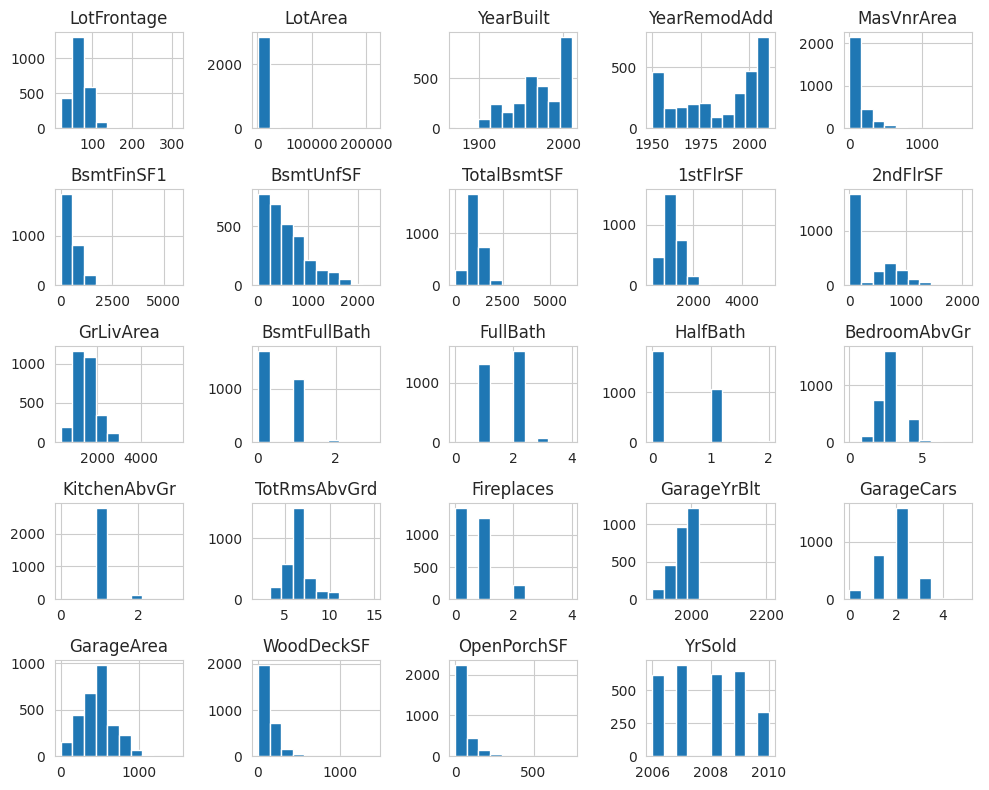

In [ ]:
df_numerical.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

Of these features we can see a couple that are right skewed, like 2ndFlrSF and BsmtFinSF1. First we need to do a statistical analysis to get the complete data of these features.

In [ ]:
df_numerical.describe()

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,YrSold
count,2433.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2917.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2760.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000
mean,69.305795,10168.114080,1971.312778,1984.264474,102.201312,441.423235,560.772104,1051.777587,1159.581706,336.483727,1500.759849,0.429894,1.568003,0.380267,2.860226,1.044536,6.451524,0.597122,1978.113406,1.766621,472.874572,93.709832,47.486811,2007.792737
std,23.344905,7886.996359,30.291442,20.894344,179.334253,455.610826,439.543659,440.766258,392.362079,428.701456,506.051045,0.524736,0.552969,0.502872,0.822693,0.214462,1.569379,0.646129,25.574285,0.761624,215.394815,126.526589,67.575493,1.314964
min,21.000000,1300.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,2006.000000
25%,59.000000,7478.000000,1953.500000,1965.000000,0.000000,0.000000,220.000000,793.000000,876.000000,0.000000,1126.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,2007.000000
50%,68.000000,9453.000000,1973.000000,1993.000000,0.000000,368.500000,467.000000,989.500000,1082.000000,0.000000,1444.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,26.000000,2008.000000
75%,80.000000,11570.000000,2001.000000,2004.000000,164.000000,733.000000,805.500000,1302.000000,1387.500000,704.000000,1743.500000,1.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,2009.000000
max,313.000000,215245.000000,2010.000000,2010.000000,1600.000000,5644.000000,2336.000000,6110.000000,5095.000000,2065.000000,5642.000000,3.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,2010.000000


There is nothing particularly noteworthy or out of the ordinary in these results.

Because of that we now are going to check for skewness.

In [ ]:
skewness = df_numerical.skew().sort_values(ascending=False)
print("Features by skewness:")
print(skewness)

Features by skewness:
LotArea         12.829025
KitchenAbvGr     4.304467
MasVnrArea       2.602589
OpenPorchSF      2.536417
WoodDeckSF       1.843380
LotFrontage      1.503278
1stFlrSF         1.470360
BsmtFinSF1       1.425722
GrLivArea        1.270010
TotalBsmtSF      1.162882
BsmtUnfSF        0.919824
2ndFlrSF         0.862118
TotRmsAbvGrd     0.758757
Fireplaces       0.733872
HalfBath         0.694924
BsmtFullBath     0.624062
BedroomAbvGr     0.326492
GarageArea       0.241301
FullBath         0.167692
YrSold           0.132467
GarageCars      -0.218373
GarageYrBlt     -0.382150
YearRemodAdd    -0.451252
YearBuilt       -0.600114
dtype: float64


We can group these features into three separate groups based on the skewness:
1. Low skewness(-0.5 to 0.5)
2. Moderate skewness(-1 to -0.5 or 0.5 to 1)
3. High skewness(<-1 or >1)

In [ ]:
high_skew = skewness[abs(skewness) > 1].index.tolist()
moderate_skew = skewness[(abs(skewness) > 0.5) & (abs(skewness) <= 1)].index.tolist()
low_skew = skewness[abs(skewness) <= 0.5].index.tolist()

print(f"\nHigh skew (>1): {high_skew}")
print(f"Moderate skew (0.5-1): {moderate_skew}")
print(f"Low skew (<0.5): {low_skew}")


High skew (>1): ['LotArea', 'KitchenAbvGr', 'MasVnrArea', 'OpenPorchSF', 'WoodDeckSF', 'LotFrontage', '1stFlrSF', 'BsmtFinSF1', 'GrLivArea', 'TotalBsmtSF']
Moderate skew (0.5-1): ['BsmtUnfSF', '2ndFlrSF', 'TotRmsAbvGrd', 'Fireplaces', 'HalfBath', 'BsmtFullBath', 'YearBuilt']
Low skew (<0.5): ['BedroomAbvGr', 'GarageArea', 'FullBath', 'YrSold', 'GarageCars', 'GarageYrBlt', 'YearRemodAdd']


1. The low skew features we can leave as is, for now.

2. The moderate skew features could benefit from transformation, but it is not critical

3. For the high skew features we should strongly consider logarithmic transformation.

 First we are going to visualize how would the high skewed data look when under a logarithmic transformation.

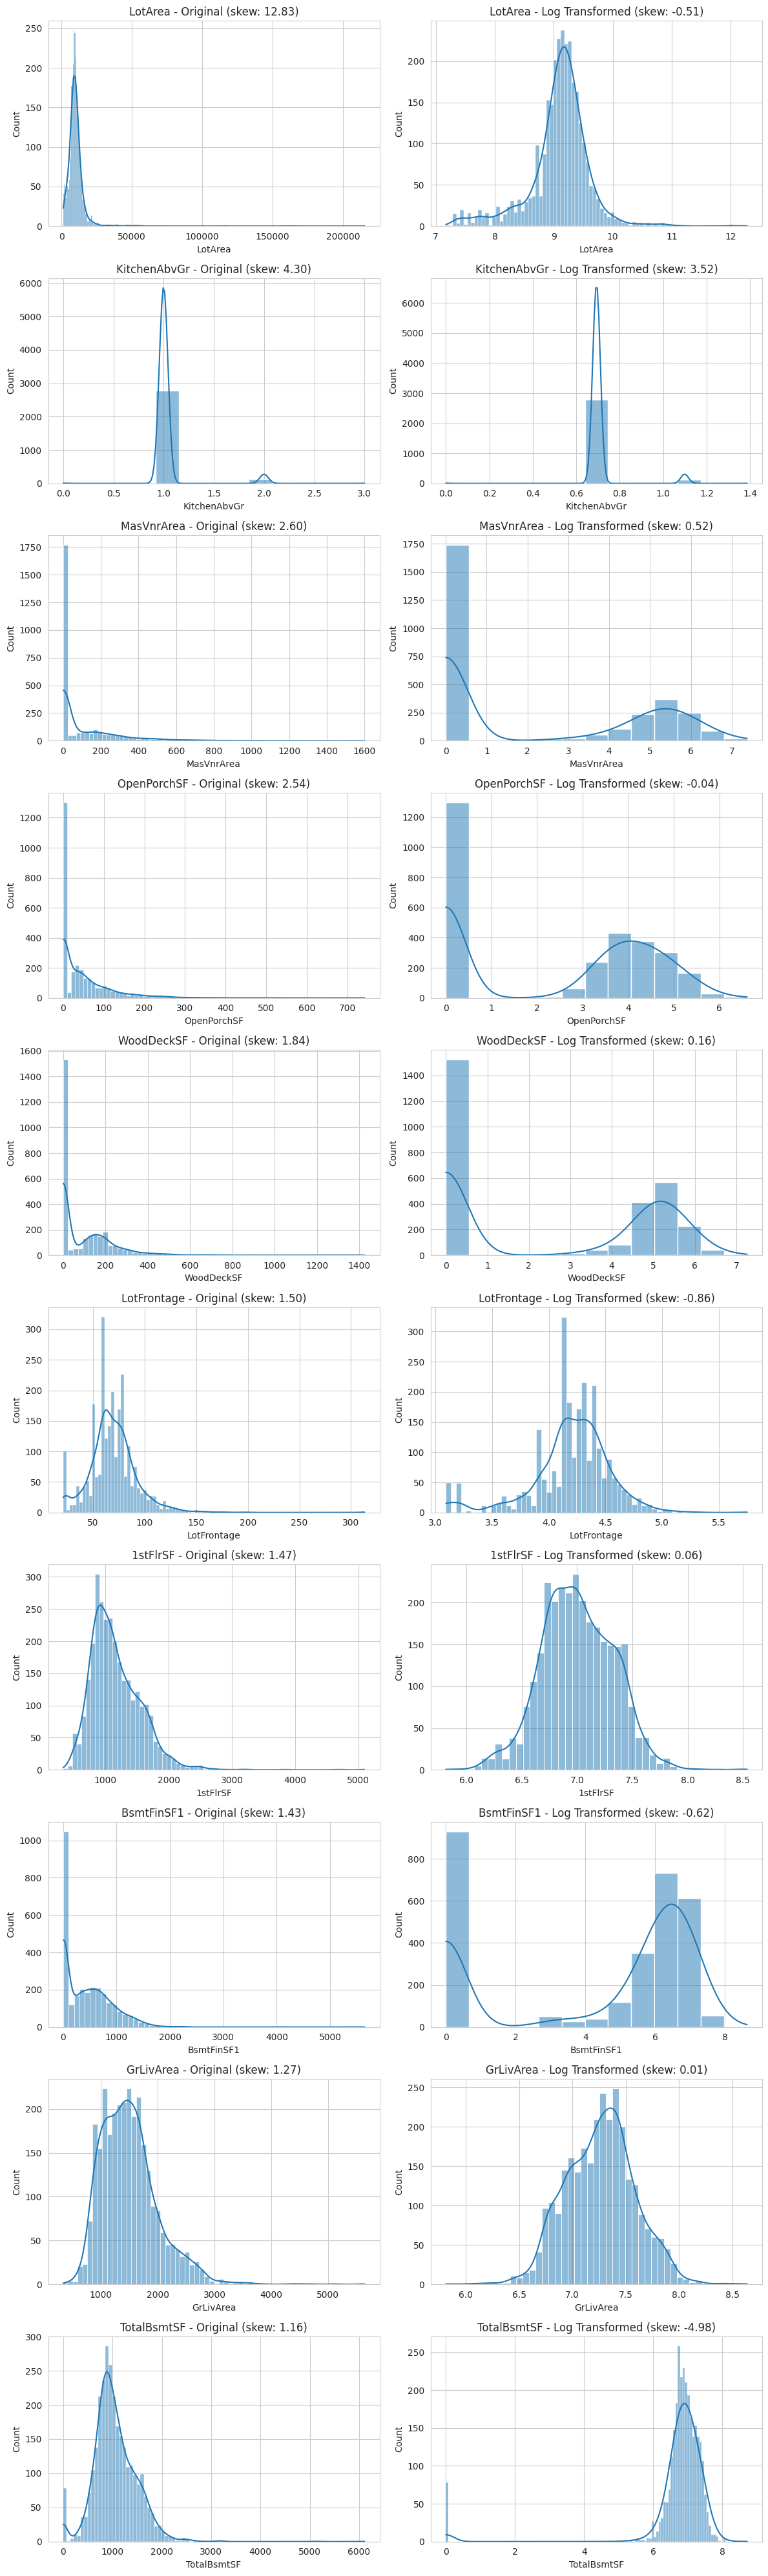

In [ ]:
skewed_features = high_skew[:11]

fig, axes = plt.subplots(len(skewed_features), 2, figsize=(12, 4*len(skewed_features)))

for i, feat in enumerate(skewed_features):
    # Original
    sns.histplot(df[feat], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{feat} - Original (skew: {df[feat].skew():.2f})')

    # Transformed
    transformed = np.log1p(df[feat])
    sns.histplot(transformed, kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f'{feat} - Log Transformed (skew: {transformed.skew():.2f})')

plt.tight_layout()
plt.show()

We can see most highly skewed features would benefit greatly, with exceptions(TotalBsmtSF and KitchenAbvGr). However we should also consider how skewed would these features look if we remove the outliers (to see if those are responsible for the skewness).

In [ ]:
for i, feat in enumerate(skewed_features):

  print(f"{feat} Skewness: {df[feat].skew()}")
  Q1 = df[feat].quantile(0.25)
  Q3 = df[feat].quantile(0.75)
  IQR = Q3 - Q1
  outliers = df[(df[feat] < Q1 - 1.5*IQR) |
              (df[feat] > Q3 + 1.5*IQR)]

  print(f"Number of outliers in {feat}: {len(outliers)}")
  print(f"{feat} Skewness without outliers: {df[~df.index.isin(outliers.index)][feat].skew():.2f}")

LotArea Skewness: 12.829024853018762
Number of outliers in LotArea: 128
LotArea Skewness without outliers: -0.09
KitchenAbvGr Skewness: 4.304466641562935
Number of outliers in KitchenAbvGr: 134
KitchenAbvGr Skewness without outliers: 0.00
MasVnrArea Skewness: 2.6025885122682517
Number of outliers in MasVnrArea: 200
MasVnrArea Skewness without outliers: 1.46
OpenPorchSF Skewness: 2.5364173160468444
Number of outliers in OpenPorchSF: 159
OpenPorchSF Skewness without outliers: 1.17
WoodDeckSF Skewness: 1.8433802126628294
Number of outliers in WoodDeckSF: 67
WoodDeckSF Skewness without outliers: 0.99
LotFrontage Skewness: 1.5032778146412304
Number of outliers in LotFrontage: 198
LotFrontage Skewness without outliers: 0.14
1stFlrSF Skewness: 1.4703601055379227
Number of outliers in 1stFlrSF: 42
1stFlrSF Skewness without outliers: 0.54
BsmtFinSF1 Skewness: 1.425722287785458
Number of outliers in BsmtFinSF1: 15
BsmtFinSF1 Skewness without outliers: 0.73
GrLivArea Skewness: 1.2700104075191514


In many cases just removing the outliers could result in greatly reduced skewness for our model, however in some cases, such as LotArea(where houses with big lot areas exist, even if rare), if we did that we could just lose critical realistic data. So we would have to check which option of the two if better.

Now we repeat the previous two steps with our Moderate skew features.

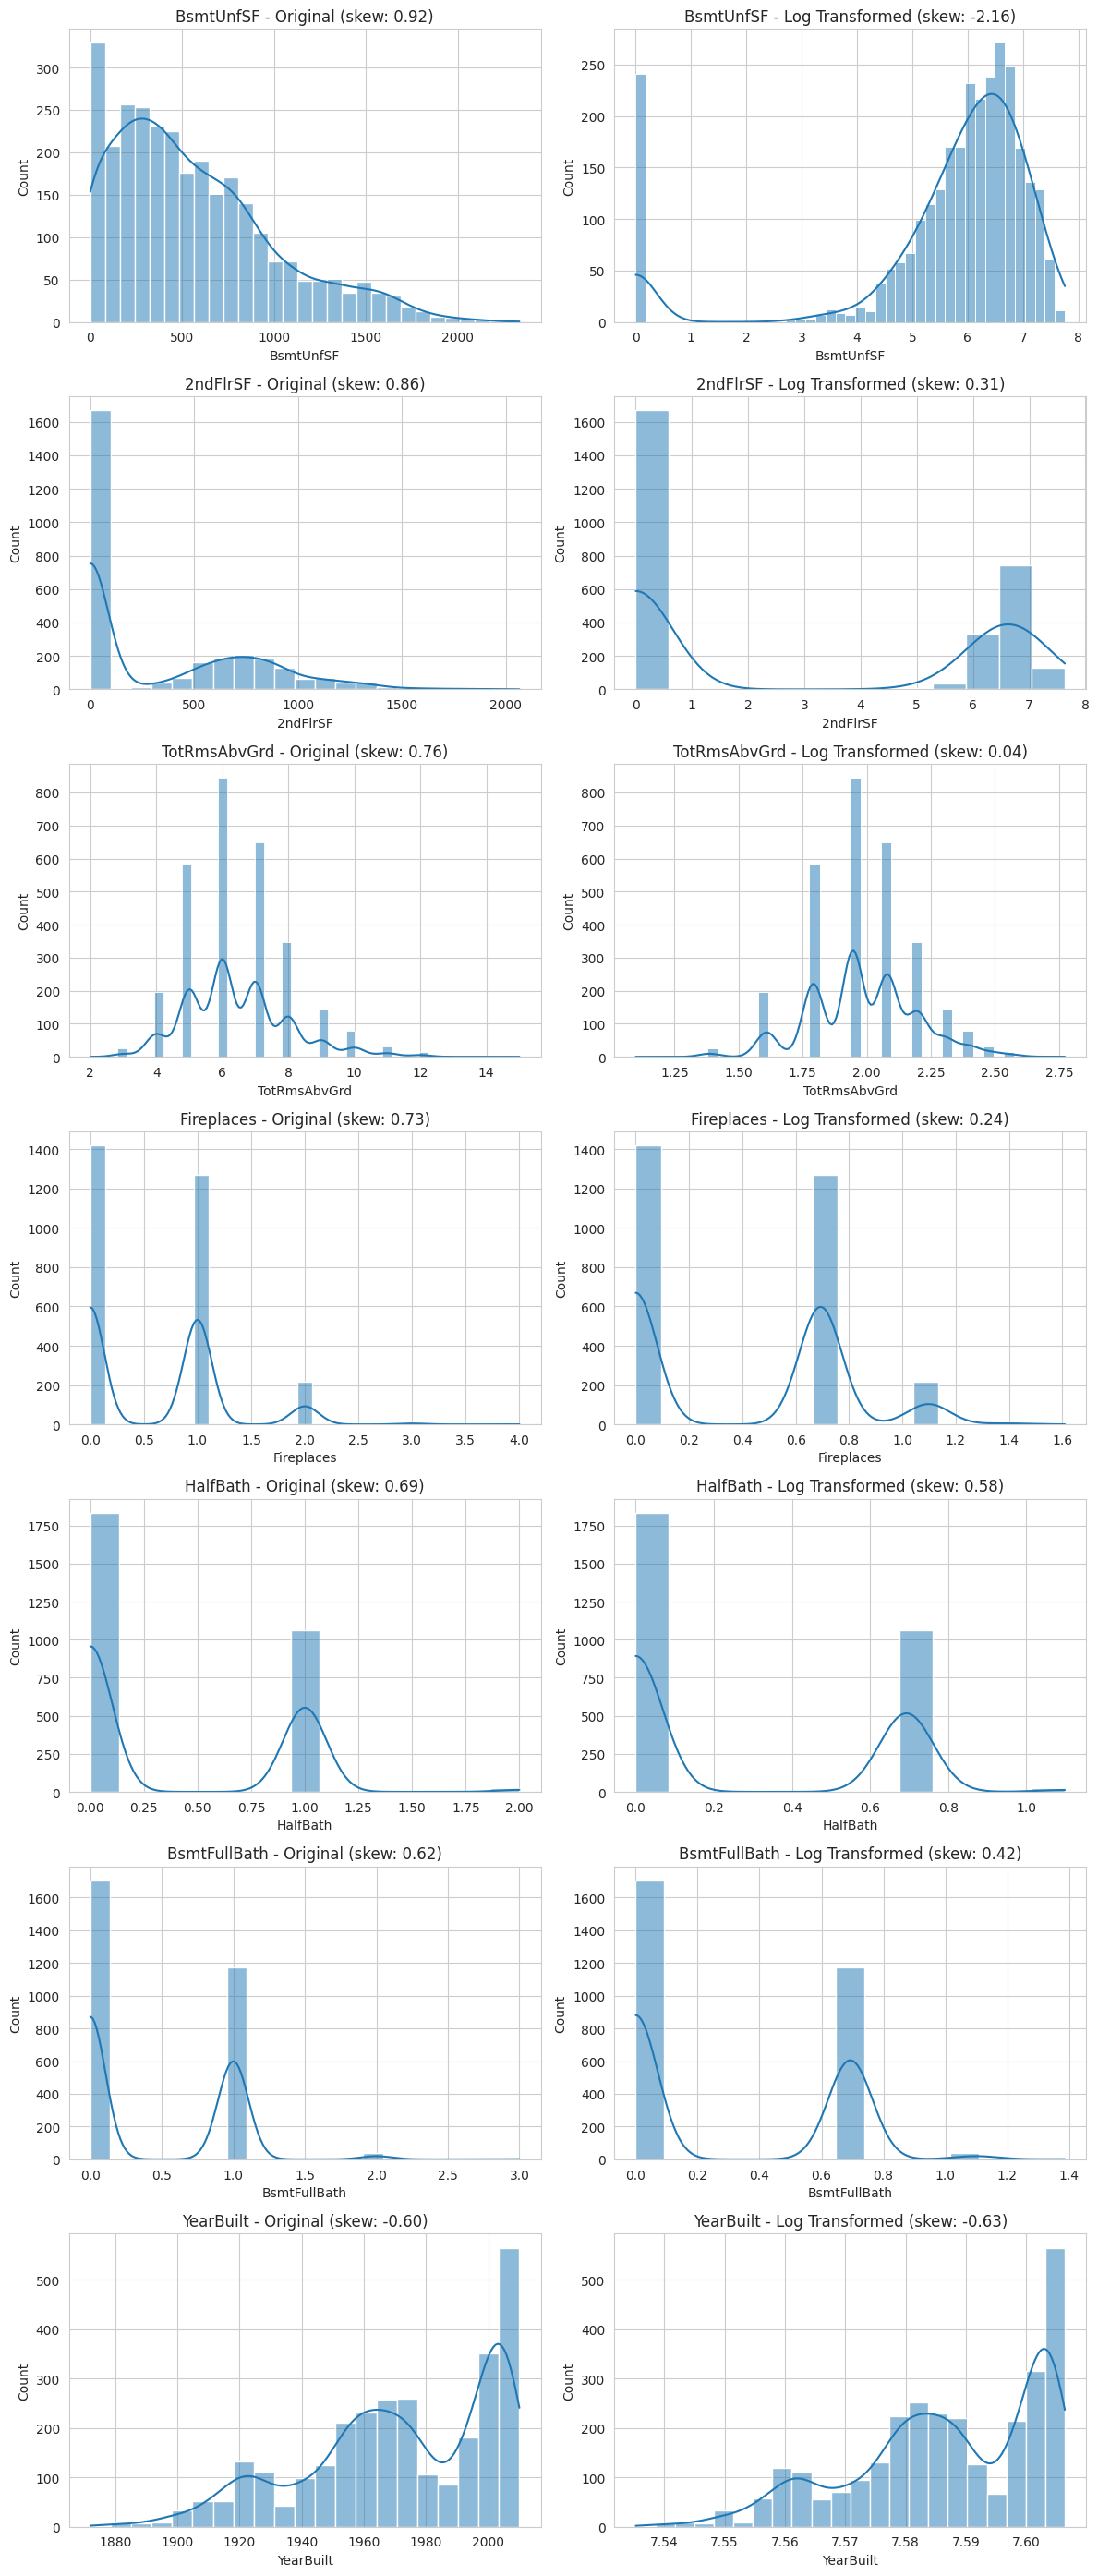

In [ ]:
skewed_features = moderate_skew[:8]

fig, axes = plt.subplots(len(skewed_features), 2, figsize=(12, 4*len(skewed_features)))

for i, feat in enumerate(skewed_features):
    # Original
    sns.histplot(df[feat], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{feat} - Original (skew: {df[feat].skew():.2f})')

    # Transformed
    transformed = np.log1p(df[feat])
    sns.histplot(transformed, kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f'{feat} - Log Transformed (skew: {transformed.skew():.2f})')

plt.tight_layout()
plt.show()

Same as last time most moderate skewed features would benefit greatly from transfomation, with exceptions.

Now to check differences in skewness with and without outliers.

In [ ]:
for i, feat in enumerate(skewed_features):

  print(f"{feat} Skewness: {df[feat].skew()}")
  Q1 = df[feat].quantile(0.25)
  Q3 = df[feat].quantile(0.75)
  IQR = Q3 - Q1
  outliers = df[(df[feat] < Q1 - 1.5*IQR) |
              (df[feat] > Q3 + 1.5*IQR)]

  print(f"Number of outliers in {feat}: {len(outliers)}")
  print(f"{feat} Skewness without outliers: {df[~df.index.isin(outliers.index)][feat].skew():.2f}")

BsmtUnfSF Skewness: 0.9198236977423032
Number of outliers in BsmtUnfSF: 53
BsmtUnfSF Skewness without outliers: 0.76
2ndFlrSF Skewness: 0.8621178325657642
Number of outliers in 2ndFlrSF: 8
2ndFlrSF Skewness without outliers: 0.81
TotRmsAbvGrd Skewness: 0.7587568676624701
Number of outliers in TotRmsAbvGrd: 51
TotRmsAbvGrd Skewness without outliers: 0.37
Fireplaces Skewness: 0.733871770878103
Number of outliers in Fireplaces: 12
Fireplaces Skewness without outliers: 0.59
HalfBath Skewness: 0.6949236492716564
Number of outliers in HalfBath: 0
HalfBath Skewness without outliers: 0.69
BsmtFullBath Skewness: 0.6240621985365326
Number of outliers in BsmtFullBath: 2
BsmtFullBath Skewness without outliers: 0.57
YearBuilt Skewness: -0.6001139748696814
Number of outliers in YearBuilt: 9
YearBuilt Skewness without outliers: -0.56


In this case only a couple would benefit(TotRmsAbvGrd and BsmtUnfSF), although only TotRmsAbvGrd would reduce the skewness enough to be worth of removing outliers.

Given that we are working toward a linear regression model, we should consider transforming as much skewed features as possible, without damaging the model. However the steps of Multivariate analysis and Data Quality Deep Dive are neccesary to reach complete conclusions. If feature engineering is necessary then we should consider doing the transformations after that, if necessary.

# Univariate Analysis - Categorical Features

First we need to divide our categorical features into nominal and ordinal.

The easiest way to check for ordinal features would be to verify the unique values each feature can have using domain knowledge(of houses and real states):

In [ ]:
for col in df_categorical.columns:
  print(f"{col}:",df[col].value_counts())

MSSubClass: MSSubClass
20     1079
60      575
50      287
120     182
30      139
70      128
160     128
80      118
90      109
190      61
85       48
75       23
45       18
180      17
40        6
150       1
Name: count, dtype: int64
MSZoning: MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64
Street: Street
Pave    2907
Grvl      12
Name: count, dtype: int64
LotShape: LotShape
Reg    1859
IR1     968
IR2      76
IR3      16
Name: count, dtype: int64
LandContour: LandContour
Lvl    2622
HLS     120
Bnk     117
Low      60
Name: count, dtype: int64
Utilities: Utilities
AllPub    2916
NoSeWa       1
Name: count, dtype: int64
LotConfig: LotConfig
Inside     2133
Corner      511
CulDSac     176
FR2          85
FR3          14
Name: count, dtype: int64
LandSlope: LandSlope
Gtl    2778
Mod     125
Sev      16
Name: count, dtype: int64
Neighborhood: Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
S

Using domain knowledge we see that the following categorical features are nominal:
 MSSubClass, MSZoning, Street, LandContour, LotConfig, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, Foundation, Heating, Electrical, GarageType, PavedDrive, Fence, MoSold, SaleType, SaleCondition, Alley, MiscFeature.

And the following categorical features are ordinal:
LotShape, Utilities, LandSlope, OverallQual, OverallCond, ExterQual, ExterCond, BsmtQual, BsmtCond, BsmtExposure, HeatingQC, CentralAir, KitchenQual, Functional, FireplaceQu, GarageFinish, GarageQual, GarageCond, BsmtFinType1, BsmtFinType2, PoolQC.

In [ ]:
df_categorical_nom = df_categorical.drop(columns=['LotShape', 'Utilities', 'LandSlope', 'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'HeatingQC', 'CentralAir', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtFinType1', 'BsmtFinType2', 'PoolQC'])
df_categorical_nom.head()

,MSSubClass,MSZoning,Street,LandContour,LotConfig,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,Foundation,Heating,Electrical,GarageType,PavedDrive,Fence,MoSold,SaleType,SaleCondition,Alley,MiscFeature
Id,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,Pave,Lvl,Inside,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,PConc,GasA,SBrkr,Attchd,Y,NaN,2,WD,Normal,NaN,NaN
2,20,RL,Pave,Lvl,FR2,Veenker,Feedr,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,NaN,CBlock,GasA,SBrkr,Attchd,Y,NaN,5,WD,Normal,NaN,NaN
3,60,RL,Pave,Lvl,Inside,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,PConc,GasA,SBrkr,Attchd,Y,NaN,9,WD,Normal,NaN,NaN
4,70,RL,Pave,Lvl,Corner,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,NaN,BrkTil,GasA,SBrkr,Detchd,Y,NaN,2,WD,Abnorml,NaN,NaN
5,60,RL,Pave,Lvl,FR2,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,PConc,GasA,SBrkr,Attchd,Y,NaN,12,WD,Normal,NaN,NaN


In [ ]:
df_categorical_nom.shape

(2919, 26)

In [ ]:
df_categorical_ord = df_categorical.drop(columns=['MSSubClass', 'MSZoning', 'Street', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'PavedDrive', 'Fence', 'MoSold', 'SaleType', 'SaleCondition', 'Alley', 'MiscFeature'])
df_categorical_ord.head()

,LotShape,Utilities,LandSlope,OverallQual,OverallCond,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,HeatingQC,CentralAir,KitchenQual,Functional,FireplaceQu,GarageFinish,GarageQual,GarageCond,PoolQC
Id,,,,,,,,,,,,,,,,,,,,,
1,Reg,AllPub,Gtl,7,5,Gd,TA,Gd,TA,No,GLQ,Unf,Ex,Y,Gd,Typ,NaN,RFn,TA,TA,NaN
2,Reg,AllPub,Gtl,6,8,TA,TA,Gd,TA,Gd,ALQ,Unf,Ex,Y,TA,Typ,TA,RFn,TA,TA,NaN
3,IR1,AllPub,Gtl,7,5,Gd,TA,Gd,TA,Mn,GLQ,Unf,Ex,Y,Gd,Typ,TA,RFn,TA,TA,NaN
4,IR1,AllPub,Gtl,7,5,TA,TA,TA,Gd,No,ALQ,Unf,Gd,Y,Gd,Typ,Gd,Unf,TA,TA,NaN
5,IR1,AllPub,Gtl,8,5,Gd,TA,Gd,TA,Av,GLQ,Unf,Ex,Y,Gd,Typ,TA,RFn,TA,TA,NaN


In [ ]:
df_categorical_ord.shape


(2919, 21)

The ordinal features will require special treatment in the encoding phase to avoid losing ordinal information. Proper ordinal encoding preserves order while maintaining category distinctions. And with that Linear models can now properly capture ordinal relationship. The next example code shows some of the mapping that has to be done during encoding.

* 'ExterQual': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
* 'BsmtFinType1': {'Unf': 0, 'LwQ': 1, 'Rec': 2, 'BLQ': 3, 'ALQ': 4, 'GLQ': 5},
* 'PavedDrive': {'N': 0, 'P': 1, 'Y': 2},
* 'LotShape': {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0},

Here we can see the percentages of total values that each option in a category takes. This will tell us how the variance of each feature.



In [ ]:
for col in df_categorical.columns:
  print(f"{col}:",(df[col].value_counts()/2919)*100)

MSSubClass: MSSubClass
20     36.964714
60     19.698527
50      9.832134
120     6.235012
30      4.761905
70      4.385063
160     4.385063
80      4.042480
90      3.734156
190     2.089757
85      1.644399
75      0.787941
45      0.616650
180     0.582391
40      0.205550
150     0.034258
Name: count, dtype: float64
MSZoning: MSZoning
RL         77.595067
RM         15.758822
FV          4.761905
RH          0.890716
C (all)     0.856458
Name: count, dtype: float64
Street: Street
Pave    99.5889
Grvl     0.4111
Name: count, dtype: float64
LotShape: LotShape
Reg    63.686194
IR1    33.162042
IR2     2.603631
IR3     0.548133
Name: count, dtype: float64
LandContour: LandContour
Lvl    89.825283
HLS     4.110997
Bnk     4.008222
Low     2.055498
Name: count, dtype: float64
Utilities: Utilities
AllPub    99.897225
NoSeWa     0.034258
Name: count, dtype: float64
LotConfig: LotConfig
Inside     73.072970
Corner     17.505995
CulDSac     6.029462
FR2         2.911956
FR3         0.479616

Now lets focus on features in which an option dominates at least 75% of the data.

In [ ]:
for col in df_categorical.columns:
  if ((df[col].value_counts().head(1).iloc[0]/2919)*100 > 75):
    print(f"{col}:",(df[col].value_counts().head(1).iloc[0]/2919)*100)

MSZoning: 77.5950668036999
Street: 99.58890030832477
LandContour: 89.82528263103802
Utilities: 99.8972250770812
LandSlope: 95.16957862281603
Condition1: 86.02261048304214
Condition2: 98.97225077081193
BldgType: 83.07639602603632
RoofStyle: 79.13669064748201
RoofMatl: 98.52689277149709
ExterCond: 86.9475847893114
BsmtCond: 89.27714970880439
BsmtFinType2: 85.40596094552929
Heating: 98.45837615621788
CentralAir: 93.28537170263789
Electrical: 91.50393970537856
Functional: 93.07982185680027
GarageQual: 89.20863309352518
GarageCond: 90.9215484755053
PavedDrive: 90.47619047619048
SaleType: 86.50222678999657
SaleCondition: 82.28845495032544


These features have low-variance and near-constant values, which tells us that  these features have low predictive power and many models might ignore or downweight these features. Depending on the percentage we can do several things here.

If the feature have 95% or more, the recommended action is to just drop it, it has a very low predictive power. In this case those features are: Street, Utilities, LandSlope, Condition2, RoofMatl and Heating. However one have to remember that some of these features could still be important for a house, like the Utilities.

If the feature is between 85 and 95%, the recommended action is to create a binary flag for rare cases. In this case those features are: LandContour, Condition1, ExterCond, BsmtCond, BsmtFinType2, CentralAir, Electrical, Functional, PavedDrive and SaleType. However some of these features are ordinal(ExterCond, BsmtCond, GarageQual, GarageCond), and depending on their statistical power we could encode them ordinally or create a binary flag.

Finally if the feature is between 75 and 85%, the recommended action is keeping the feature or adding a binary flag, it would depend on the feature itself and whats more aproppiate. In this case those features are: MSZoning, BldgType, RoofStyle and SaleCondition.

Now we are going to check the cardinality of our categorical features.

In [ ]:
# Identify categorical columns
categorical_cols = df_categorical.columns

# Calculate cardinality
cardinality = {}
for col in categorical_cols:
    n_unique = df[col].nunique()
    n_total = len(df)
    cardinality[col] = {
        'unique_values': n_unique,
        'percentage': (n_unique / n_total) * 100,
        'sample': df[col].unique()[:5]  # First 5 unique values
    }

# Sort by highest cardinality
sorted_cardinality = sorted(cardinality.items(),
                           key=lambda x: x[1]['unique_values'],
                           reverse=True)

print("Features by cardinality (highest first):")
for col, info in sorted_cardinality[:10]:  # Top 10
    print(f"\n{col}:")
    print(f"  - Unique values: {info['unique_values']}")
    print(f"  - % of total rows: {info['percentage']:.2f}%")
    print(f"  - Examples: {info['sample']}")

Features by cardinality (highest first):

Neighborhood:
  - Unique values: 25
  - % of total rows: 0.86%
  - Examples: ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel']

MSSubClass:
  - Unique values: 16
  - % of total rows: 0.55%
  - Examples: [ 60  20  70  50 190]

Exterior2nd:
  - Unique values: 16
  - % of total rows: 0.55%
  - Examples: ['VinylSd' 'MetalSd' 'Wd Shng' 'HdBoard' 'Plywood']

Exterior1st:
  - Unique values: 15
  - % of total rows: 0.51%
  - Examples: ['VinylSd' 'MetalSd' 'Wd Sdng' 'HdBoard' 'BrkFace']

MoSold:
  - Unique values: 12
  - % of total rows: 0.41%
  - Examples: [ 2  5  9 12 10]

OverallQual:
  - Unique values: 10
  - % of total rows: 0.34%
  - Examples: [7 6 8 5 9]

Condition1:
  - Unique values: 9
  - % of total rows: 0.31%
  - Examples: ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe']

OverallCond:
  - Unique values: 9
  - % of total rows: 0.31%
  - Examples: [5 8 6 7 4]

SaleType:
  - Unique values: 9
  - % of total rows: 0.31%
  - Examples: ['WD' 'New' 'COD' '

We have to identify features with high cardinality, to then decide what to do with them

In [ ]:
def classify_cardinality(df, col):
    """
    Classify cardinality level
    """
    n_unique = df[col].nunique()
    n_total = len(df)
    ratio = n_unique / n_total

    if ratio > 0.8:
        return "EXTREME", "Near-unique identifier (like ID)"
    elif ratio > 0.5:
        return "VERY HIGH", "Almost as many categories as rows"
    elif ratio > 0.2:
        return "HIGH", "Many categories relative to dataset"
    elif ratio > 0.05:
        return "MODERATE", "Somewhat high, needs attention"
    elif n_unique > 20:
        return "MEDIUM", "Many categories but reasonable"
    else:
        return "LOW", "Few categories, manageable"

# Apply classification
for col in categorical_cols:
    level, desc = classify_cardinality(df, col)
    print(f"{col:20s}: {level:10s} - {desc}")

MSSubClass          : LOW        - Few categories, manageable
MSZoning            : LOW        - Few categories, manageable
Street              : LOW        - Few categories, manageable
LotShape            : LOW        - Few categories, manageable
LandContour         : LOW        - Few categories, manageable
Utilities           : LOW        - Few categories, manageable
LotConfig           : LOW        - Few categories, manageable
LandSlope           : LOW        - Few categories, manageable
Neighborhood        : MEDIUM     - Many categories but reasonable
Condition1          : LOW        - Few categories, manageable
Condition2          : LOW        - Few categories, manageable
BldgType            : LOW        - Few categories, manageable
HouseStyle          : LOW        - Few categories, manageable
OverallQual         : LOW        - Few categories, manageable
OverallCond         : LOW        - Few categories, manageable
RoofStyle           : LOW        - Few categories, manageable
Roof

Based on these results, we can say for sure that only one feature have high enough cardinality to warrant an specific type of encoding for the model.

In the case of neighborhood we have four options of encoding:
1.  Frequency Encoding
2. Target Encoding (AFTER train/test split to avoid data leakage)
3. Group Rare Categories and then consider encoding
4. Domain-Based Grouping(ex. map each neighborhood to a cardinal direction(north,south,etc.))

For the rest of categories we can use different encoding methods depending on their specific cardinality and if they are ordinal or nominal:

In [ ]:
def ames_encoding_decision_matrix():
    """
    Complete encoding decisions for Ames dataset
    """
    matrix = {
        'ExterQual': {'type': 'ordinal_quality', 'encoding': 'ordinal', 'notes': 'Map Po=1, Fa=2, TA=3, Gd=4, Ex=5'},
        'ExterCond': {'type': 'ordinal_quality', 'encoding': 'ordinal', 'notes': 'Same as above, handle missing with TA'},
        'BsmtQual': {'type': 'ordinal_quality', 'encoding': 'ordinal', 'notes': 'Missing=0 (no basement), add has_basement flag'},
        'BsmtCond': {'type': 'ordinal_quality', 'encoding': 'ordinal', 'notes': 'Missing=0 (no basement)'},
        'BsmtExposure': {'type': 'ordinal_other', 'encoding': 'ordinal', 'notes': 'Map No=0, Mn=1, Av=2, Gd=3'},
        'BsmtFinType1': {'type': 'ordinal_finish', 'encoding': 'ordinal', 'notes': 'Map Unf=0 through GLQ=5'},
        'BsmtFinType2': {'type': 'ordinal_finish', 'encoding': 'ordinal', 'notes': 'Same as above'},
        'KitchenQual': {'type': 'ordinal_quality', 'encoding': 'ordinal', 'notes': 'Standard quality mapping'},
        'FireplaceQu': {'type': 'ordinal_quality', 'encoding': 'ordinal', 'notes': 'Missing=0 (no fireplace), add has_fireplace'},
        'GarageQual': {'type': 'ordinal_quality', 'encoding': 'ordinal', 'notes': 'Missing=0 (no garage)'},
        'GarageCond': {'type': 'ordinal_quality', 'encoding': 'ordinal', 'notes': 'Missing=0 (no garage)'},
        'HeatingQC': {'type': 'ordinal_quality', 'encoding': 'ordinal', 'notes': 'Standard quality mapping'},
        'CentralAir': {'type': 'binary', 'encoding': 'binary', 'notes': 'Y=1, N=0'},
        'Street': {'type': 'binary', 'encoding': 'binary', 'notes': 'Pave=1, Grvl=0'},
        'Alley': {'type': 'binary', 'encoding': 'binary', 'notes': 'Has alley or not'},
        'PavedDrive': {'type': 'ordinal_other', 'encoding': 'ordinal', 'notes': 'Y=2, P=1, N=0'},
        'LotShape': {'type': 'ordinal_other', 'encoding': 'ordinal', 'notes': 'Reg=3, IR1=2, IR2=1, IR3=0'},
        'LandSlope': {'type': 'ordinal_other', 'encoding': 'ordinal', 'notes': 'Gtl=2, Mod=1, Sev=0'},
        'Functional': {'type': 'ordinal_other', 'encoding': 'ordinal', 'notes': 'Typ=7 down to Sal=0'},
        'Neighborhood': {'type': 'nominal_high', 'encoding': 'target/freq', 'notes': '25+ categories, use target encoding'},
        'MSZoning': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories, one-hot encode'},
        'LotConfig': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories'},
        'LandContour': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories'},
        'Condition1': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories'},
        'Condition2': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories, mostly one value'},
        'BldgType': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories'},
        'HouseStyle': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories'},
        'RoofStyle': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories'},
        'RoofMatl': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories, mostly one value'},
        'Exterior1st': {'type': 'nominal_high', 'encoding': 'frequency', 'notes': 'Many exterior types'},
        'Exterior2nd': {'type': 'nominal_high', 'encoding': 'frequency', 'notes': 'Many exterior types'},
        'MasVnrType': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Include None category'},
        'Foundation': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories'},
        'Heating': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories, mostly GasA'},
        'Electrical': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories'},
        'GarageType': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Include NoGarage category'},
        'MiscFeature': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Include None category'},
        'SaleType': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories'},
        'SaleCondition': {'type': 'nominal_low', 'encoding': 'one-hot', 'notes': 'Few categories'},
        'MoSold': {'type': 'cyclic', 'encoding': 'sin/cos', 'notes': 'Cyclical encoding essential'},
    }

    print("\n📋 AMES DATASET - COMPLETE ENCODING DECISION MATRIX")
    print("="*70)
    print(f"{'Feature':20s} {'Type':20s} {'Encoding':15s} Notes")
    print("-"*70)

    for feature, info in matrix.items():
        if feature in df.columns:
            print(f"{feature:20s} {info['type']:20s} {info['encoding']:15s} {info['notes']}")

    return matrix

# Display the matrix
encoding_matrix = ames_encoding_decision_matrix()


📋 AMES DATASET - COMPLETE ENCODING DECISION MATRIX
Feature              Type                 Encoding        Notes
----------------------------------------------------------------------
ExterQual            ordinal_quality      ordinal         Map Po=1, Fa=2, TA=3, Gd=4, Ex=5
ExterCond            ordinal_quality      ordinal         Same as above, handle missing with TA
BsmtQual             ordinal_quality      ordinal         Missing=0 (no basement), add has_basement flag
BsmtCond             ordinal_quality      ordinal         Missing=0 (no basement)
BsmtExposure         ordinal_other        ordinal         Map No=0, Mn=1, Av=2, Gd=3
BsmtFinType1         ordinal_finish       ordinal         Map Unf=0 through GLQ=5
BsmtFinType2         ordinal_finish       ordinal         Same as above
KitchenQual          ordinal_quality      ordinal         Standard quality mapping
FireplaceQu          ordinal_quality      ordinal         Missing=0 (no fireplace), add has_fireplace
GarageQual     

# Univariate Analysis - Guiding Questions answers

3. Is SalePrice normally distributed, or is it skewed?

SalePrice is right-skewed.

10. Can and should i create binary flags to represent certain categorical features?

Yes, if the top option of a categorical feature represent between 75 to 95% of total values, then it shall be replaced with a binary flag of having the top option or not. This is done during the Data processing phase.

11. Which skewed features might benefit from log transformation?

Many, but mainly the following ones: LotArea, MasVnrArea, OpenPorchSF, WoodDeckSF, LotFrontage, 1stFlrSF, BsmtFinSF1, GrLivArea.
Worth mentioning that removing outliers would also help in reducing the skew of the features in many cases.

# Multivariate Analysis

Here we are gonna analyse relationships between variables. With certain focus on the relationship between features and our target(SalePrice)

# Multivariate Analysis - Feature vs Target Analysis

Here we need to see how each feature affects our target(SalePrice)

We are going to select some important continuous features to see linear relationships, outliers, or clusters.
Starting with the comparison between sale price and Above grade (ground) living area square feet.

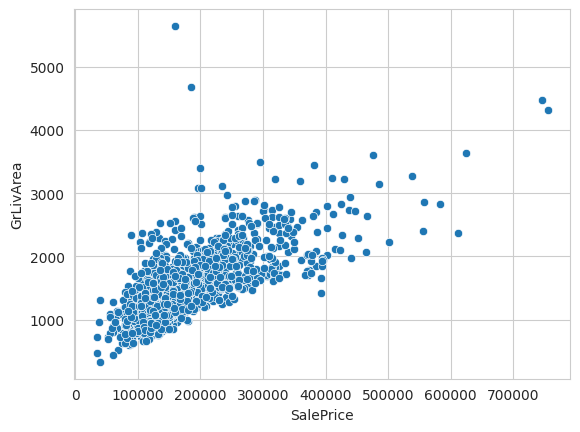

In [ ]:
sns.scatterplot(x="SalePrice", y="GrLivArea", data=df)
plt.show()

Here we can see a linear relationship
Now lets compare sale price with year built

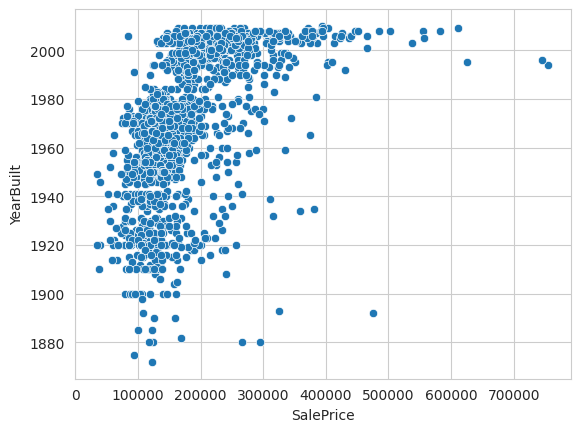

In [ ]:
sns.scatterplot(x="SalePrice", y="YearBuilt", data=df)
plt.show()

There is also a relationship, the higher the year, the higher the price, even if just slightly.
Finally lets compare the sale price with the lot area

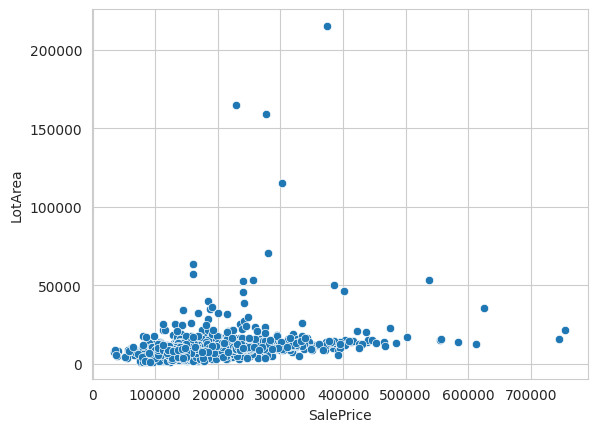

In [ ]:
sns.scatterplot(x="SalePrice", y="LotArea", data=df)
plt.show()

Here there does not appear to be a linear relationship.

For discrete variables we can use a boxplot. and for certain categorical we can use violinPlots

Lets start with overrall quality vs sale price

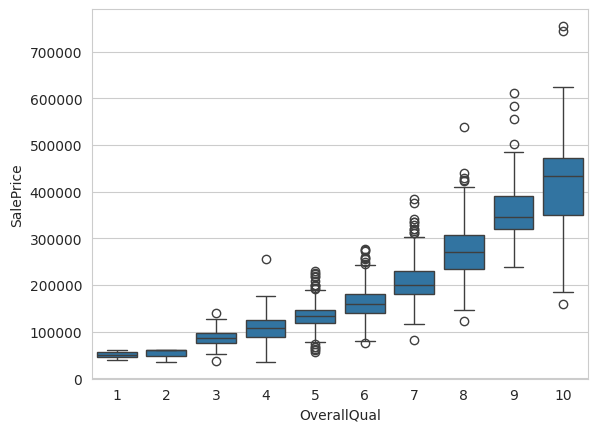

In [ ]:
sns.boxplot(x="OverallQual", y="SalePrice", data=df)
plt.show()

We can see easily how the price increments with overall quality.
Now lets see neighborhood vs sale price

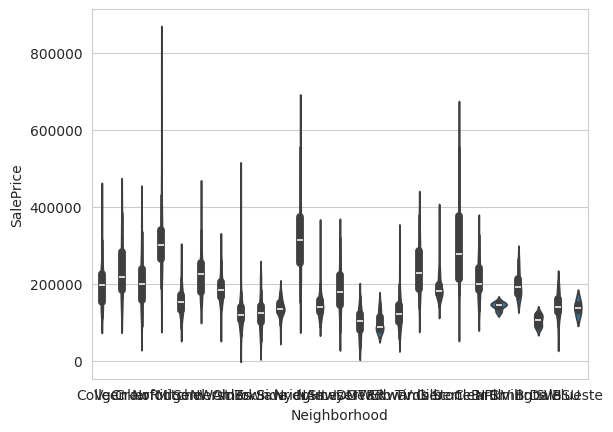

In [ ]:
sns.violinplot(x="Neighborhood", y="SalePrice", data=df)
plt.show()

We can see that the effect that neighborhoods have on the sale price are quite notorious.

Finally lets see sale price vs Heating quality

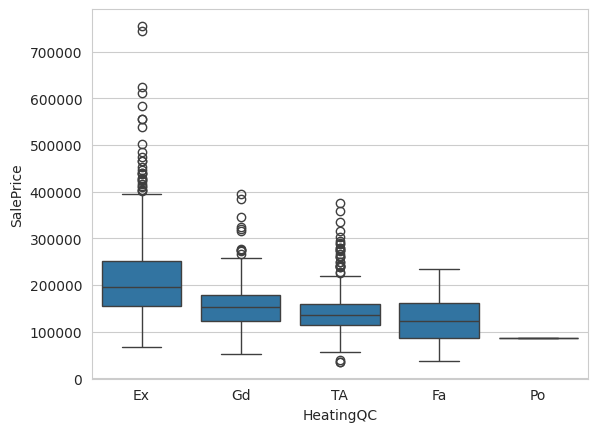

In [ ]:
sns.boxplot(x="HeatingQC", y="SalePrice", data=df)
plt.show()

Here we can see an small but notable effect on the sale price.

Anyway, checking each feature one by one against our target would take too much time and effort, to contrast every numerical feature to our target we can simply use correlation analysis.

# Multivariate Analysis - Correlation Analysis

Here we are going to check all the correlation between numerical features and our target(SalePrice)

The best way to do this is using a heatmap

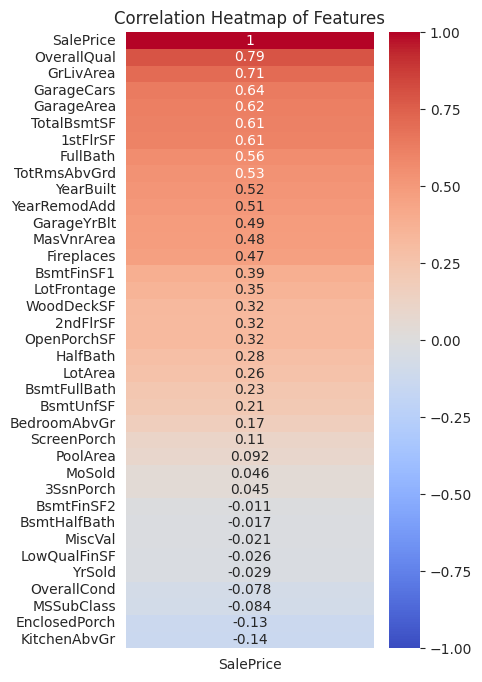

In [ ]:

corr_matrix = df.corr(numeric_only=True)

target_corr = corr_matrix[['SalePrice']].sort_values(by='SalePrice', ascending=False)
plt.figure(figsize=(4, 8))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Features')
plt.show()

We see that the numerical features correlation with SalePrice range from -0.14 to 0.79.
Now we can observe which features are above 0.5 or below -0.5 in correlation, those features have what we can classify as a high correlation with our target.

In [ ]:
target_corr[(target_corr['SalePrice'] > 0.5) | (target_corr['SalePrice'] < -0.5)]

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


And these features will be very useful towards making a regression model. That means we will most likely keep these features(OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF, FullBath, TotRmsAbvGrd, YearBuilt, YearRemodAdd) in one way or another(maybe after being combined with others during feature engineering) for the data processing. On the other hand the rest of the  numerical features could be useful for feature engineering and in case they are not we can remove them.

Now lets see the correlation between numerical values, this will tell us if there are features that are redundant.

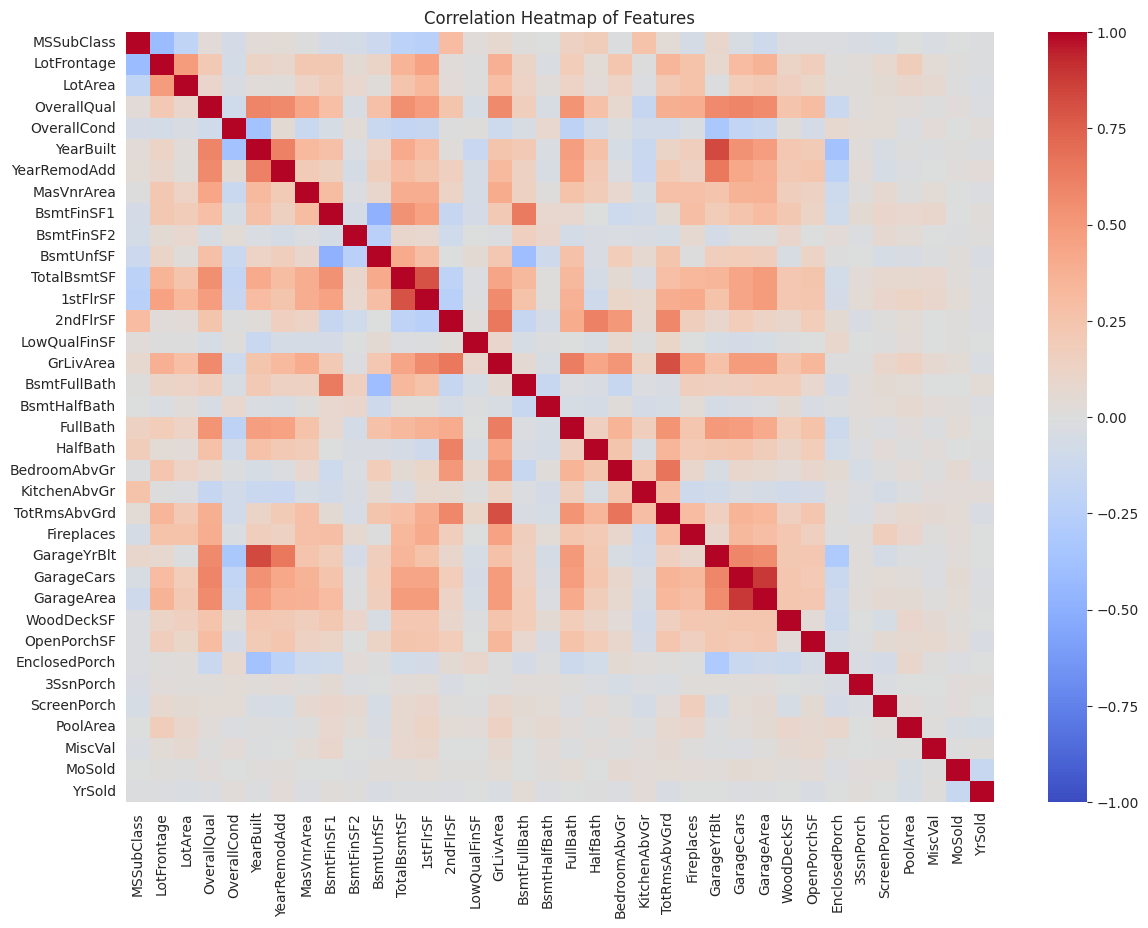

In [ ]:
df_cor = df.drop(columns=['SalePrice'])
corr_matrix = df_cor.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Features')
plt.show()

Not a lot of high correlation between pairs to be seen.

Now lets see which pairs feature correlations above 0.75 or below -0.75

In [ ]:
threshold = 0.75
high_corr = corr_matrix.stack()
high_corr = high_corr[((high_corr > threshold) | (high_corr < -threshold)) & (high_corr < 1.0)]
print("Pairs with high correlation:")
high_corr

Pairs with high correlation:


,,0
YearBuilt,GarageYrBlt,0.834812
TotalBsmtSF,1stFlrSF,0.801670
1stFlrSF,TotalBsmtSF,0.801670
GrLivArea,TotRmsAbvGrd,0.808354
TotRmsAbvGrd,GrLivArea,0.808354
GarageYrBlt,YearBuilt,0.834812
GarageCars,GarageArea,0.889700
GarageArea,GarageCars,0.889700


This features are the ones with multicollinearity, which means we most likely have to remove one of the two or combine them to make a more precise feature.

Here is important to note those which already have high correlation with salePrice, of those there is: GarageCars with GarageArea, TotRmsAbvGrd with GrLivArea, YearBuilt with GarageYrBuilt and 1stFlrSF with TotalBsmtSF. Of these we have options:

*  GarageCars with GarageArea: The best option here is probably remove GarageCars, given that GarageArea is a more versatile and realistic feature to have for the model.

*  TotRmsAbvGrd with GrLivArea: Here we can just take GrLivArea and remove TotRmsAbvGrd, however we can also make a function of these two features in feature engineering.

*  YearBuilt with GarageYrBuilt: GarageYrBuilt is probably the most irrelevant here and we can easily remove it.

*  1stFlrSF with TotalBsmtSF: Here we probably want to combine all square feet measuring features in one, TotalSF that improves our model accesibility.

# Multivariate Analysis - Guiding Questions answers

2. Are there any features that seem redundant or could be derived from others?

GarageCars does not add as much value as GarageArea, same with YearBuilt compared to GarageYrBuilt.

7. Which features show the strongest relationship with SalePrice?

OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF, FullBath, TotRmsAbvGrd, YearBuilt, YearRemodAdd

9. Can and should i create new features by combining existing ones?

Yes and yes, combining features like all SF ones that simplifies the total area of a house or combining TotRmsAbvGrd with GrLivArea to create a feature that shows how large is each room in average.

# Data Quality Deep Dive

Here we are going to mainly identify and analyze missing data and also to detect outliers for our target(SalePrice).



# Data Quality Deep Dive - Identify and Analyze Missing Data

We are going to check and visualize missing data across all features and target, distinguish what to do with columns and rows with missing data.

First we are going to check the percentage of missing values by column

In [ ]:
df.isnull().sum().sort_values(ascending=False)/2919*100


,0
PoolQC,99.657417
MiscFeature,96.402878
Alley,93.216855
Fence,80.438506
MasVnrType,60.500171
...,...
EnclosedPorch,0.000000
MoSold,0.000000
MiscVal,0.000000
YrSold,0.000000


Now lets see a plot of features with at least 0.1% of missing(Null) values

<Axes: >

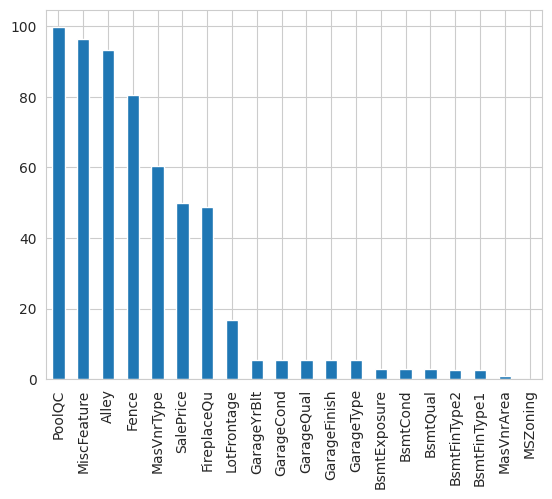

In [ ]:
df_miss = df.isnull().sum().sort_values(ascending=False)/2919*100
df_miss = df_miss[df_miss > 0.1]
df_miss.plot(kind='bar')

Now, of these features only those with at least 50% of missing data should be candidates to be removed or added to other features, however we need to understand these features first.

*  MasVnrType(>60% of missing values): This may mean houses with no masonry, so it could be feature engineered to have an additional value that represents not having masonry.

*  Fence(>80% of missing values): This refers to houses with no fence, it probably needs to be feature engineered according to features in which an option have between 75% and 85% of values, which means possibly a binary flag(between having fence and not having).

*  Alley(>90% of missing values): This refers to houses with no alley access, it probably needs to be feature engineered according to features in which an option have between 85% and 95% of values, which means a binary flag(between having alley and not having).

*  MiscFeature(>95% of missing values): This refers to houses with no miscellaneous feature, it probably needs to be removed similar to features in which an option have above 95% of values. Because of the low predicting power

* PoolQC(>99% of missing values): This refers to houses with no pool, it probably needs to be removed similar to features in which an option have above 95% of values. Because of the low predicting power

For features with less than 50% of missing data, we shall use different methods to fill the Null values depending on the type of feature:

* Categorical feature in which house not having such feature is represented as Null: Add additional value of not having such feature(none) and fill Null values with that value.
* Numerical feature in which house not having such feature is represented as Null: Fill Null values with 0.
* Float numerical feature: Fill Null values with mean.
* Integer numerical feature: Fill Null values with median.
* Categorical ordinal feature: Fill Null values with median.
* Categorical nominal feature: Fill Null values with mode.

In the case of the target(SalePrice), any row with missing data(Null SalePrice) is to be dropped, because they will not add any value to the model.

# Data Quality Deep Dive - Target Outlier Detection

Here we are going to check for data points that are significantly different from others in our target. Because outliers can heavily influence models.

First we are going to check for outliers using a boxplot:

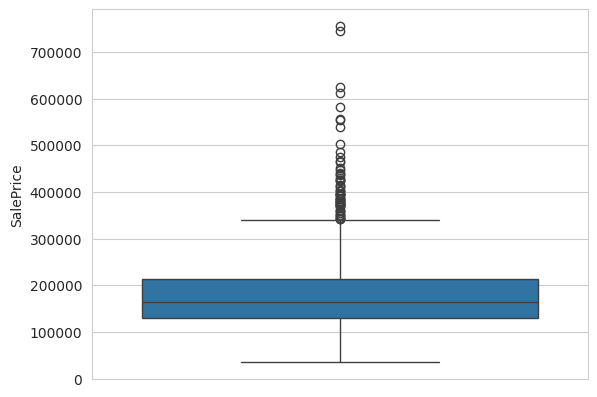

In [ ]:
sns.boxplot(y="SalePrice", data=df)
plt.show()

Here the circles represent outliers, We have many outliers above certain price range.
After a log transformation however we dont have as many

<Axes: ylabel='SalePrice'>

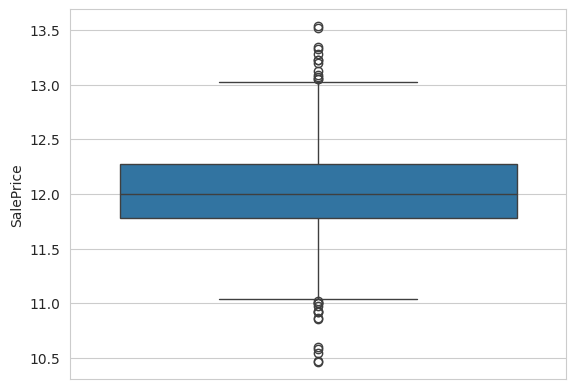

In [ ]:
transformed = np.log1p(df['SalePrice'])
sns.boxplot(y=transformed)

We need to check if those outliers could be removed, or if they have reason to be where they are. We are going to contrast them to certain quality features.


TARGET VARIABLE OUTLIER ANALYSIS
Target: SalePrice

Distribution Statistics:
  Mean: $180,921.20
  Median: $163,000.00
  Std: $79,442.50

Outlier Boundaries:
  Lower: $3,937.50
  Upper: $340,037.50

Outlier Counts:
  Total outliers: 61 (2.09%)
  Low outliers: 0
  High outliers: 61


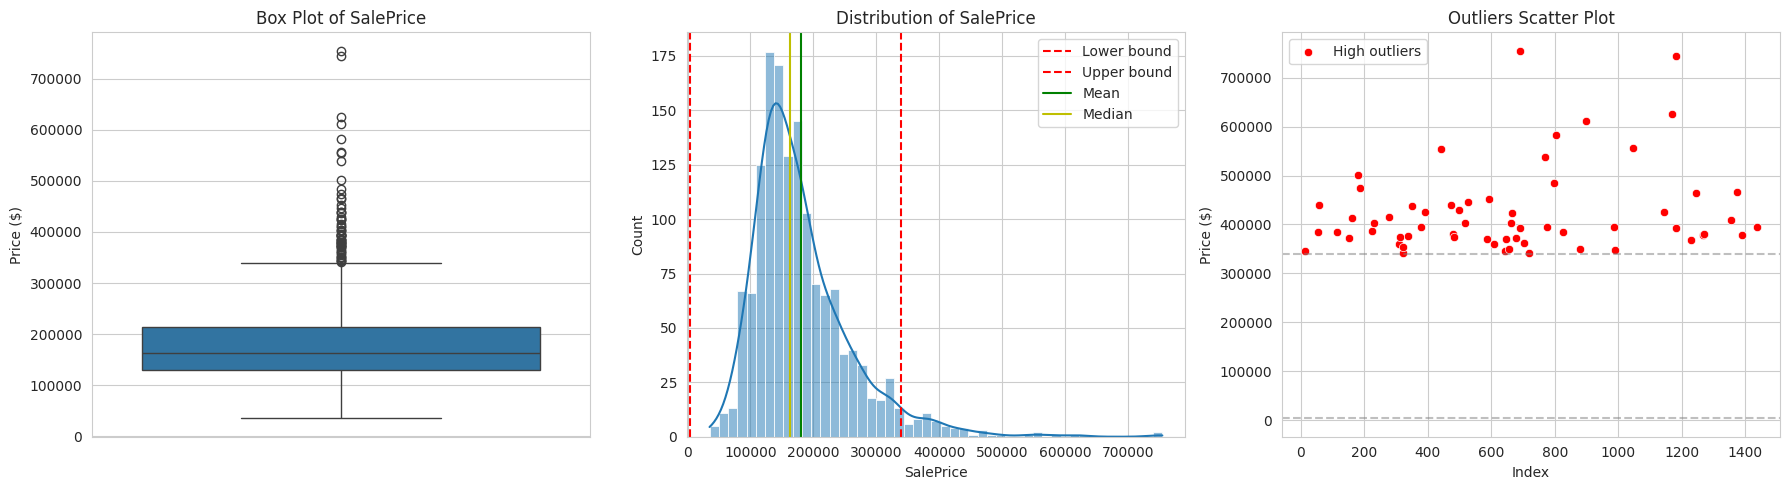


🔍 High-Value Outlier Characteristics:
       OverallQual    GrLivArea      SalePrice
count    61.000000    61.000000      61.000000
mean      8.754098  2456.918033  425954.180328
std       0.849622   627.271400   89557.255611
min       7.000000  1419.000000  341000.000000
25%       8.000000  2018.000000  372500.000000
50%       9.000000  2364.000000  394617.000000
75%       9.000000  2728.000000  440000.000000
max      10.000000  4476.000000  755000.000000


In [ ]:
def analyze_target_outliers(df, target='SalePrice'):
    """
    Comprehensive analysis of outliers in target variable
    """
    # Calculate outlier boundaries
    Q1 = df[target].quantile(0.25)
    Q3 = df[target].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[target] < lower_bound) | (df[target] > upper_bound)]
    low_outliers = df[df[target] < lower_bound]
    high_outliers = df[df[target] > upper_bound]

    print(f"\n{'='*60}")
    print("TARGET VARIABLE OUTLIER ANALYSIS")
    print(f"{'='*60}")
    print(f"Target: {target}")
    print(f"\nDistribution Statistics:")
    print(f"  Mean: ${df[target].mean():,.2f}")
    print(f"  Median: ${df[target].median():,.2f}")
    print(f"  Std: ${df[target].std():,.2f}")
    print(f"\nOutlier Boundaries:")
    print(f"  Lower: ${lower_bound:,.2f}")
    print(f"  Upper: ${upper_bound:,.2f}")
    print(f"\nOutlier Counts:")
    print(f"  Total outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"  Low outliers: {len(low_outliers)}")
    print(f"  High outliers: {len(high_outliers)}")

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Box plot
    sns.boxplot(y=df[target], ax=axes[0])
    axes[0].set_title(f'Box Plot of {target}')
    axes[0].set_ylabel('Price ($)')

    # Distribution with outlier boundaries
    sns.histplot(df[target], kde=True, ax=axes[1])
    axes[1].axvline(lower_bound, color='r', linestyle='--', label='Lower bound')
    axes[1].axvline(upper_bound, color='r', linestyle='--', label='Upper bound')
    axes[1].axvline(df[target].mean(), color='g', linestyle='-', label='Mean')
    axes[1].axvline(df[target].median(), color='y', linestyle='-', label='Median')
    axes[1].set_title(f'Distribution of {target}')
    axes[1].legend()

    # Zoom in on outliers
    if len(high_outliers) > 0:
        sns.scatterplot(data=high_outliers, x=high_outliers.index, y=target, ax=axes[2], color='red', label='High outliers')
    if len(low_outliers) > 0:
        sns.scatterplot(data=low_outliers, x=low_outliers.index, y=target, ax=axes[2], color='blue', label='Low outliers')
    axes[2].axhline(lower_bound, color='gray', linestyle='--', alpha=0.5)
    axes[2].axhline(upper_bound, color='gray', linestyle='--', alpha=0.5)
    axes[2].set_title('Outliers Scatter Plot')
    axes[2].set_xlabel('Index')
    axes[2].set_ylabel('Price ($)')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # Analyze outlier characteristics
    if len(high_outliers) > 0:
        print("\n🔍 High-Value Outlier Characteristics:")
        print(high_outliers[['OverallQual', 'GrLivArea', 'Neighborhood', target]].describe())

    return outliers, low_outliers, high_outliers

# Run analysis
target_outliers, low_target, high_target = analyze_target_outliers(df)


TARGET VARIABLE OUTLIER ANALYSIS
Target: SalePrice

Distribution Statistics:
  Mean: $180,921.20
  Median: $163,000.00
  Std: $79,442.50

Outlier Boundaries:
  Lower: $3,937.50
  Upper: $340,037.50

Outlier Counts:
  Total outliers: 61 (2.09%)
  Low outliers: 0
  High outliers: 61


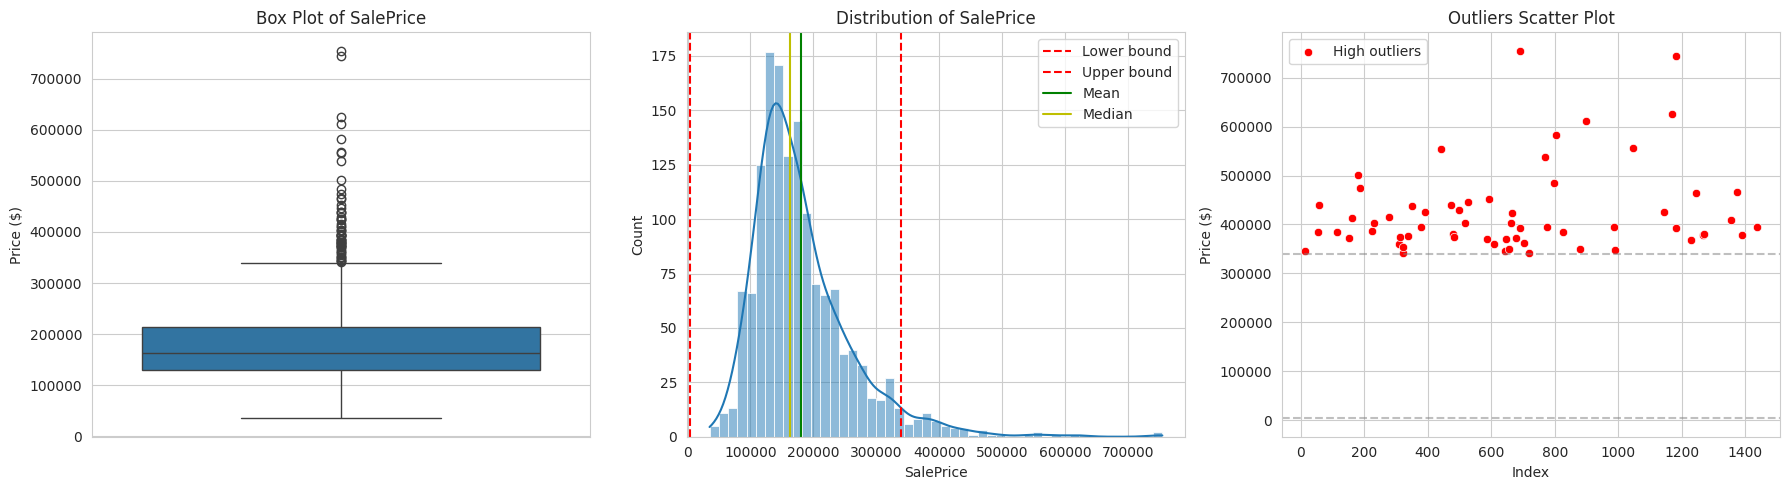


🔍 High-Value Outlier Characteristics:
       OverallQual    GrLivArea      SalePrice
count    61.000000    61.000000      61.000000
mean      8.754098  2456.918033  425954.180328
std       0.849622   627.271400   89557.255611
min       7.000000  1419.000000  341000.000000
25%       8.000000  2018.000000  372500.000000
50%       9.000000  2364.000000  394617.000000
75%       9.000000  2728.000000  440000.000000
max      10.000000  4476.000000  755000.000000

TARGET OUTLIER TREATMENT DECISION

Checking high-value outliers legitimacy:
  - 50/61 high outliers are in premium neighborhoods
  - 58/61 high outliers have quality 8+
  - 15/61 high outliers are in top 25% by size

✅ DECISION: KEEP high-value outliers - They appear to be legitimate luxury homes
   Action: Consider log transformation to handle skewness


In [ ]:
def decide_target_outlier_treatment(df, target='SalePrice'):
    """
    Make informed decision about target outliers
    """
    outliers, low_outliers, high_outliers = analyze_target_outliers(df, target)

    print(f"\n{'='*60}")
    print("TARGET OUTLIER TREATMENT DECISION")
    print(f"{'='*60}")

    # Check if outliers are legitimate
    if len(high_outliers) > 0:
        print("\nChecking high-value outliers legitimacy:")

        # Check 1: Are they in premium neighborhoods?
        premium_neighborhoods = ['NoRidge', 'NridgHt', 'StoneBr', 'Timber']
        high_premium = high_outliers[high_outliers['Neighborhood'].isin(premium_neighborhoods)]
        print(f"  - {len(high_premium)}/{len(high_outliers)} high outliers are in premium neighborhoods")

        # Check 2: Do they have high quality?
        high_quality = high_outliers[high_outliers['OverallQual'] >= 8]
        print(f"  - {len(high_quality)}/{len(high_outliers)} high outliers have quality 8+")

        # Check 3: Are they large homes?
        large_homes = high_outliers[high_outliers['GrLivArea'] > high_outliers['GrLivArea'].quantile(0.75)]
        print(f"  - {len(large_homes)}/{len(high_outliers)} high outliers are in top 25% by size")

        # Decision
        if len(high_premium) > 0.5 * len(high_outliers) or len(high_quality) > 0.5 * len(high_outliers):
            print("\n✅ DECISION: KEEP high-value outliers - They appear to be legitimate luxury homes")
            print("   Action: Consider log transformation to handle skewness")
        else:
            print("\n⚠️ DECISION: INVESTIGATE further - Some high outliers may be data errors")
            print("   Action: Manually review suspicious cases")

    # Check low-value outliers
    if len(low_outliers) > 0:
        print("\nChecking low-value outliers legitimacy:")

        # Check for possible data errors (e.g., price too low for features)
        suspicious_low = low_outliers[
            (low_outliers['OverallQual'] >= 5) &
            (low_outliers['GrLivArea'] > 1000) &
            (low_outliers['Neighborhood'].isin(premium_neighborhoods))
        ]

        if len(suspicious_low) > 0:
            print(f"  - Found {len(suspicious_low)} low outliers with good features - possible data errors!")
            print("\n⚠️ DECISION: REVIEW these cases - They might be errors:")
            print(suspicious_low[['Neighborhood', 'OverallQual', 'GrLivArea', target]])
        else:
            print("  - Low outliers appear to be legitimate lower-value properties")
            print("\n✅ DECISION: KEEP low-value outliers - They represent the lower end of market")

    return outliers

# Make decision
target_outliers = decide_target_outlier_treatment(df)

Here we checked whether the outliers house were in premium neighborhoods, have a high quality(high OverallQual) or are large homes(high GrLivArea). And based on this we should keep high-value outliers - They appear to be legitimate luxury homes

# Data Quality Deep Dive - Guiding Questions answers

4. Are there any extreme values that might be errors or legitimate luxury homes?

No, there are no low-value outliers, and high value outliers appear to be luxury homes.

8. Why are values missing? Is it truly missing or "does not exist"?

In the case of features like Alley, Fence or MasVnrType. Each one have Null values on houses that are missing that feature.



# Final Preprocessing Decisions

Here we are going to give detailed actions that should be done to each feature and our target on the next step.

# Final Preprocessing Decisions - Target

Because of the skewed distribution and the outliers for our target variable:

*  SalePrice: Log transformation

Also we need to remove rows without SalePrice (with that value as Null).

# Final Preprocessing Decisions - Numerical features(32 in total)

For the model we need to specially keep those features which are the strongest predictors of SalePrice. Based on the Feature vs Target Analysis those are:

GrLivArea
GarageCars
GarageArea
TotalBsmtSF
1stFlrSF
FullBath
TotRmsAbvGrd
YearBuilt
YearRemodAdd

However of these we only are truly going to keep as is the following ones:

GarageArea
YearBuilt
YearRemodAdd
GrLivArea
TotRmsAbvGrd

That is because we intend to put the rest(and GrLivArea, TotRmsAbvGrd) through feature engineering to try and make more useful features, specifically using the following formulas:

* TotalOutdoorSF = OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch + WoodDeckSF

* TotalBath = FullBath + 0.5xHalfBath + BsmtFullBath + 0.5xBsmtHalfBath

* TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF + 0.5xLowQualFinSF + TotalPorchSF

* AvgRoomSize = GrLivArea/TotRmsAbvGrd

With these four new features, that are going to replace some of the strong predictors, we hope to get a more complete overview of the house in a more simple way for the future regression model. However we are also using some features that have skewed data, for that reason we should consider logarithmic transformation if they are also skewed after creating them.

Specifically we can see what each feature accomplishes:

* TotalOutdoorSF: Combines each porch and wood deck square feet feature into one that includes them all, that helps houses which have rare types of porches or wood decks to create a more meaningful variable.
* TotalBath: Combines each bath amount feature into one that includes them all, also giving half value to half baths, to be more fair. This help collect all bath data in one feature and more easily compare bath amount in each house.
* TotalSF: Combines each square feet feature into one that includes them all, also giving half value to low quality finish. This can helps manage the total space of the house in a more simple way that more easily compare different houses.
* AvgRoomSize: Divides the above grade living area between total rooms above grade, giving that way the average room area. This allows to check if the house have small or big rooms more easily.

All remanining numerical features have too low predicting power, or are simply too bad at predicting our target. So are going to be dropped in the data preparation phase.

In the end, we are left with these(9) numerical features:

GarageArea
YearBuilt
YearRemodAdd
GrLivArea
TotRmsAbvGrd
AvgSFPerRoom
TotalSF
TotalPorchSF
TotalBath

As mentioned during the data quality deep dive we are going to fill Null values(during data preparation) as following:
* Numerical feature in which house not having such feature is represented as Null: Fill Null values with 0.
* Float numerical feature: Fill Null values with mean.
* Integer numerical feature: Fill Null values with median.

# Final Preprocessing Decisions - Categorical features(47 in total)

-For the model we need to specially keep those features which are the strongest predictors of SalePrice. Based on the Feature vs Target Analysis those are:

OverallQual

-In terms of encoding is important that categorical features have no Null values, for that reason we should fill those values(during data preparation) as following:

* Categorical feature in which house not having such feature is represented as Null: Add additional value of not having such feature(none) and fill Null values with that value.
* Categorical ordinal feature: Fill Null values with median.
* Categorical nominal feature: Fill Null values with mode.


-Now we can focus on categorical features we are going to have to drop.

-The following features we are going to need to drop for above 95% of missing values:

MiscFeature PoolQC

-And the following features we are going to need to drop for low-variance and near-constant values:

Electrical  GarageType  PavedDrive HeatingRoofMatl  Condition2 Street Utilities LandSlope

-----------------------------------------------------------------------

-Now in terms of nominal categorical features we have several that have certain details we have to address first.

-The following features have an option that dominates above 75% of the data:

LandContour
Condition1
MSSubClass  
MSZoning
BldgType  
RoofStyle  
SaleCondition

-For these features we should encode them using a binary flag(feature_not_topOption) that is 1 when the house does not have the top option and 0 otherwise.

-The following features have above 75% of Null values:

Alley
Fence

-For these features we should encode them using a binary flag(has_feature) that is 1 when the house does have the feature and 0 otherwise.

-The following features have above 60% of Null values:

MasVnrType

-For this feature we should add an additional option that represents the house not having the feature, then encode.

-The following features have high cardinality:

Neighborhood

-For this feature we will group the rare categories as option(s), turning this feature into one with medium cardinality.

-The rest of nominal features have no special details.

-After doing these required actions for the nominal features we can encode them, if they are not already encoded, the following features will go through one-hot encoding because of low cardinality:

MasVnrType
LotConfig HouseStyle SaleType Foundation

-The following features will go through frequency encoding because of medium cardinality:

Exterior1st
Exterior2nd
Neighborhood

-The following feature will go through cyclical encoding because it is a time type feature:

MoSold

--------------------------------------------------------------------

-Now in terms of ordinal categorical features, we have some with certain details we have to address first:

-The following features have an option that dominates above 75% of the data:

BsmtFinType2
CentralAir GarageCond GarageQual Functional

-For these features we should encode them using a binary flag(feature_not_topOption) that is 1 when the house does not have the top option and 0 otherwise.

-The following features are already ordinal encoded:

OverallQual OverallCond

-The rest of ordinal features have no special details.

-After doing these required actions for the ordinal features we can encode them, if they are not already encoded, the following features will go through ordinal encoding:

BsmtCond
ExterQual
GarageFinish
KitchenQual FireplaceQu BsmtFinType1 BsmtQual LotShape
BsmtExposure
HeatingQC
ExterCond

----------------------------------------------------------------------

-In the end, we are left with the(14) following categorical features that have to be encoded with binary flags:

LandContour
Condition1
MSSubClass
MSZoning
BldgType
RoofStyle
SaleCondition
Alley
Fence
BsmtFinType2
CentralAir
GarageCond
GarageQual
Functional

-And the(3) following categorical features that have to be encoded using frequency encoding:

Exterior1st
Exterior2nd
Neighborhood

-And the(5) following categorical features that have to be encoded using one-hot encoding:

MasVnrType
LotConfig
HouseStyle
SaleType
Foundation

-And the(1) following categorical feature that have to be encoded using cyclical encoding:

MoSold

-And the(11) following categorical features that have to be encoded using ordinal encoding:

BsmtCond
ExterQual
GarageFinish
KitchenQual
FireplaceQu
BsmtFinType1
BsmtQual
LotShape
BsmtExposure
HeatingQC
ExterCond

-And the(2) following categorical features that are already ordinal encoded:

OverallQual
OverallCond

-For a total of 36 categorical features left, 45 features left and 46 columns in total for the future model.